# Restaurant Item Sales Forecasting

## Project Introduction

Accurate demand forecasting helps businesses make informed decisions about inventory, staffing, production, pricing, and future planning. For restaurants, understanding how item demand changes across different days, months, quarters, and years can improve operational efficiency and reduce the risks associated with overestimating or underestimating future sales.

This project analyzes historical item-level sales data from multiple restaurants. The available datasets contain daily sales transactions, item prices, calorie information, and restaurant details. Exploratory data analysis will be used to identify sales patterns, compare restaurant performance, and determine which items contribute most strongly to overall demand and revenue.

## Project Objective

The objective of this project is to help Fresh Analytics understand and predict demand for items sold across different restaurants. The analysis will:

* Combine the restaurant, item, and sales datasets into one analytical dataset.
* Examine sales patterns across days, months, quarters, and years.
* Compare sales and revenue performance among restaurants.
* Identify popular items and other important item-level characteristics.
* Engineer calendar-based features for forecasting.
* Build and compare linear regression, random forest, and XGBoost regression models.
* Evaluate the models using root mean squared error (RMSE), with the final six months of historical data reserved for testing.
* Use the best-performing model to forecast item sales for the following year.


In [3]:
# File and folder path management
from pathlib import Path

# Data manipulation and numerical operations
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Improved table display inside Jupyter Notebook
from IPython.display import display


# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.options.display.float_format = "{:,.2f}".format

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 1. Dataset Loading

The sales forecasting data is stored across three CSV files:

- `sales.csv` contains daily item-level sales records.
- `items.csv` contains item, restaurant, calorie, and cost information.
- `resturants.csv` contains restaurant names and identifiers.

Each file is loaded into a raw DataFrame. Separate working copies are then created for cleaning, merging, feature engineering, and analysis.

In [4]:
# Folder containing the project CSV files
DATA_DIR = Path("data/raw")

# Load the original CSV files into raw DataFrames
restaurants_raw_df = pd.read_csv(DATA_DIR / "resturants.csv")
items_raw_df = pd.read_csv(DATA_DIR / "items.csv")
sales_raw_df = pd.read_csv(
    DATA_DIR / "sales.csv",
    parse_dates=["date"]
)

# Create working copies for the project
restaurants_df = restaurants_raw_df.copy()
items_df = items_raw_df.copy()
sales_df = sales_raw_df.copy()

print("Data files loaded successfully.")

Data files loaded successfully.


In [6]:
# Summarize the loaded DataFrames
dataframe_summary = pd.DataFrame({
    "DataFrame": ["restaurants_df", "items_df", "sales_df"],
    "Rows": [
        restaurants_df.shape[0],
        items_df.shape[0],
        sales_df.shape[0]
    ],
    "Columns": [
        restaurants_df.shape[1],
        items_df.shape[1],
        sales_df.shape[1]
    ]
})

display(dataframe_summary)

,DataFrame,Rows,Columns
0,restaurants_df,6,2
1,items_df,100,5
2,sales_df,109600,4


## 2. Preliminary Data Inspection

Before cleaning, merging, or transforming the data, the three working DataFrames are inspected to understand their structures and confirm that they were loaded correctly. This inspection includes reviewing sample records, column names, dimensions, and data types.


In [7]:
# Preview the restaurant dataset
print("RESTAURANTS DATASET")
display(restaurants_df.head())

# Preview the item dataset
print("ITEMS DATASET")
display(items_df.head())

# Preview the sales dataset
print("SALES DATASET")
display(sales_df.head())

RESTAURANTS DATASET


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe


ITEMS DATASET


,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


SALES DATASET


,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.00
1,2019-01-01,4,26.42,22.00
2,2019-01-01,12,4.87,7.00
3,2019-01-01,13,4.18,12.00
4,2019-01-01,16,3.21,136.00


In [8]:
# Inspect the structure and data types of each dataset
print("RESTAURANTS DATASET INFORMATION")
restaurants_df.info()

print("\nITEMS DATASET INFORMATION")
items_df.info()

print("\nSALES DATASET INFORMATION")
sales_df.info()

RESTAURANTS DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      6 non-null      int64
 1   name    6 non-null      str  
dtypes: int64(1), str(1)
memory usage: 228.0 bytes

ITEMS DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    str    
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 4.0 KB

SALES DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date     

In [9]:
print(sales_df.columns.tolist())
print(sales_df["date"].dtype)

['date', 'item_id', 'price', 'item_count']
datetime64[us]


In [10]:
# Display descriptive statistics for each dataset
print("RESTAURANTS DATASET — DESCRIPTIVE STATISTICS")
display(restaurants_df.describe().T)

print("\nITEMS DATASET — DESCRIPTIVE STATISTICS")
display(items_df.describe().T)

print("\nSALES DATASET — DESCRIPTIVE STATISTICS")
display(sales_df.describe().T)

RESTAURANTS DATASET — DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
id,6.00,3.50,1.87,1.00,2.25,3.50,4.75,6.00



ITEMS DATASET — DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
id,100.00,50.50,29.01,1.00,25.75,50.50,75.25,100.00
store_id,100.00,3.52,1.71,1.00,2.00,4.00,5.00,6.00
kcal,100.00,536.73,202.21,78.00,406.25,572.50,638.25,"1,023.00"
cost,100.00,11.76,8.99,1.39,5.28,7.62,18.79,53.98



SALES DATASET — DESCRIPTIVE STATISTICS


,count,mean,min,25%,50%,75%,max,std
date,109600,2020-07-01 12:00:00,2019-01-01 00:00:00,2019-10-01 18:00:00,2020-07-01 12:00:00,2021-04-01 06:00:00,2021-12-31 00:00:00,NaN
item_id,"109,600.00",50.50,1.00,25.75,50.50,75.25,100.00,28.87
price,"109,600.00",11.76,1.39,5.28,7.62,18.79,53.98,8.95
item_count,"109,600.00",6.34,0.00,0.00,0.00,0.00,570.00,30.00


In [11]:
# Check each dataset for missing values and exact duplicate rows
data_quality_summary = pd.DataFrame({
    "Dataset": [
        "Restaurants",
        "Items",
        "Sales"
    ],
    "Missing Values": [
        restaurants_df.isna().sum().sum(),
        items_df.isna().sum().sum(),
        sales_df.isna().sum().sum()
    ],
    "Duplicate Rows": [
        restaurants_df.duplicated().sum(),
        items_df.duplicated().sum(),
        sales_df.duplicated().sum()
    ]
})

display(data_quality_summary)

,Dataset,Missing Values,Duplicate Rows
0,Restaurants,0,0
1,Items,0,0
2,Sales,0,0


## 3. Data Merging

The sales, item, and restaurant datasets are combined into one analytical DataFrame. Item identifiers connect sales records to item information, while restaurant identifiers connect each item to its associated restaurant.

Descriptive column names are assigned during this process to distinguish item and restaurant information clearly.

In [12]:
# Rename columns to make identifiers and descriptions unambiguous
items_for_merge = items_df.rename(columns={
    "id": "item_id",
    "store_id": "restaurant_id",
    "name": "item_name",
    "kcal": "calories",
    "cost": "item_cost"
})

restaurants_for_merge = restaurants_df.rename(columns={
    "id": "restaurant_id",
    "name": "restaurant_name"
})

# Add item information to each sales record
merged_df = sales_df.merge(
    items_for_merge,
    on="item_id",
    how="left",
    validate="many_to_one"
)

# Add restaurant information to each sales record
merged_df = merged_df.merge(
    restaurants_for_merge,
    on="restaurant_id",
    how="left",
    validate="many_to_one"
)

# Confirm that the merges preserved all sales records
assert len(merged_df) == len(sales_df), \
    "The merge unexpectedly changed the number of sales records."

assert merged_df["item_name"].notna().all(), \
    "Some sales records did not match an item."

assert merged_df["restaurant_name"].notna().all(), \
    "Some items did not match a restaurant."

print(f"Merge completed successfully: {merged_df.shape[0]:,} rows")
display(merged_df.head(15))

Merge completed successfully: 109,600 rows


,date,item_id,price,item_count,restaurant_id,item_name,calories,item_cost,restaurant_name
0,2019-01-01,3,29.22,2.00,1,Sweet Fruity Cake,931,29.22,Bob's Diner
1,2019-01-01,4,26.42,22.00,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner
2,2019-01-01,12,4.87,7.00,1,Fantastic Sweet Cola,478,4.87,Bob's Diner
3,2019-01-01,13,4.18,12.00,1,Sweet Frozen Soft Drink,490,4.18,Bob's Diner
4,2019-01-01,16,3.21,136.00,1,Frozen Milky Smoothy,284,3.21,Bob's Diner
5,2019-01-01,19,2.89,108.00,1,Strawberry Smoothy,145,2.89,Bob's Diner
6,2019-01-01,21,23.23,13.00,1,Amazing Fish with Vegetables Meal,269,23.23,Bob's Diner
7,2019-01-01,23,10.86,10.00,1,Awesome Sweet Lamb Cake,671,10.86,Bob's Diner
8,2019-01-01,27,26.21,1.00,6,Steak Meal,607,26.21,Surfs Up
9,2019-01-01,35,4.36,1.00,6,Blue Ribbon Cocktail,456,4.36,Surfs Up


In [13]:
merged_df = merged_df.rename(columns={
    "item_count": "units_sold"
})

## 4. Feature Engineering

Calendar-based features are extracted from the date column to support the analysis of daily, monthly, quarterly, and yearly sales patterns. These features will also provide the forecasting models with information about seasonality and changes in demand over time.

Revenue is calculated for business analysis by multiplying the number of units sold by the unit price. Because revenue is derived from the target variable, it will not be included as an input feature when training the forecasting models.

In [14]:
# Create calendar-based features from the date column
merged_df["year"] = merged_df["date"].dt.year
merged_df["quarter"] = merged_df["date"].dt.quarter
merged_df["month"] = merged_df["date"].dt.month
merged_df["month_name"] = merged_df["date"].dt.month_name()
merged_df["day_of_month"] = merged_df["date"].dt.day
merged_df["day_of_week"] = merged_df["date"].dt.dayofweek
merged_df["day_name"] = merged_df["date"].dt.day_name()
merged_df["week_of_year"] = merged_df["date"].dt.isocalendar().week.astype(int)

# Create cyclical calendar features to represent repeating seasonal patterns
merged_df["month_sin"] = np.sin(
    2 * np.pi * merged_df["month"] / 12
)
merged_df["month_cos"] = np.cos(
    2 * np.pi * merged_df["month"] / 12
)

merged_df["day_of_week_sin"] = np.sin(
    2 * np.pi * merged_df["day_of_week"] / 7
)
merged_df["day_of_week_cos"] = np.cos(
    2 * np.pi * merged_df["day_of_week"] / 7
)

merged_df["day_of_year"] = merged_df["date"].dt.dayofyear

merged_df["day_of_year_sin"] = np.sin(
    2 * np.pi * merged_df["day_of_year"] / 365.25
)
merged_df["day_of_year_cos"] = np.cos(
    2 * np.pi * merged_df["day_of_year"] / 365.25
)

# Identify weekends: Saturday = 5 and Sunday = 6
merged_df["is_weekend"] = (
    merged_df["day_of_week"] >= 5
).astype(int)

# Calculate revenue for exploratory and business analysis
merged_df["revenue"] = (
    merged_df["units_sold"] * merged_df["price"]
)

# Preview the engineered features
display(
    merged_df[
        [
            "date",
            "item_id",
            "restaurant_name",
            "units_sold",
            "year",
            "quarter",
            "month",
            "month_name",
            "day_of_month",
            "day_of_week",
            "day_name",
            "week_of_year",
            "is_weekend",
            "revenue"
        ]
    ].head()
)

,date,item_id,restaurant_name,units_sold,year,quarter,month,month_name,day_of_month,day_of_week,day_name,week_of_year,is_weekend,revenue
0,2019-01-01,3,Bob's Diner,2.00,2019,1,1,January,1,1,Tuesday,1,0,58.44
1,2019-01-01,4,Bob's Diner,22.00,2019,1,1,January,1,1,Tuesday,1,0,581.24
2,2019-01-01,12,Bob's Diner,7.00,2019,1,1,January,1,1,Tuesday,1,0,34.09
3,2019-01-01,13,Bob's Diner,12.00,2019,1,1,January,1,1,Tuesday,1,0,50.16
4,2019-01-01,16,Bob's Diner,136.00,2019,1,1,January,1,1,Tuesday,1,0,436.56


In [15]:
# Confirm that the engineered features contain no missing values
engineered_columns = [
    "year",
    "quarter",
    "month",
    "month_name",
    "day_of_month",
    "day_of_week",
    "day_name",
    "week_of_year",
    "is_weekend",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "revenue"
]

assert merged_df[engineered_columns].notna().all().all(), \
    "One or more engineered features contain missing values."

# Summarize the time period and dataset coverage
date_coverage_summary = pd.DataFrame({
    "Metric": [
        "Beginning date",
        "Ending date",
        "Unique dates",
        "Years represented",
        "Unique restaurants",
        "Unique items"
    ],
    "Value": [
        merged_df["date"].min().date(),
        merged_df["date"].max().date(),
        merged_df["date"].nunique(),
        merged_df["year"].nunique(),
        merged_df["restaurant_id"].nunique(),
        merged_df["item_id"].nunique()
    ]
})

display(date_coverage_summary)

,Metric,Value
0,Beginning date,2019-01-01
1,Ending date,2021-12-31
2,Unique dates,1096
3,Years represented,3
4,Unique restaurants,6
5,Unique items,100


## 5. Exploratory Data Analysis

Exploratory data analysis is performed to identify overall sales patterns and examine how demand changes across time, restaurants, and items. The analysis includes daily, weekly, monthly, quarterly, and yearly comparisons, followed by restaurant- and item-level evaluations.

### 5.1 Sales Distribution and Potential Outliers

The distribution of units sold is examined before analyzing overall sales patterns. Because an unusually large sales count may represent a legitimate high-demand item or date, extreme values are investigated rather than automatically removed.


,Units Sold
count,"109,600.00"
mean,6.34
std,30.00
min,0.00
90%,7.00
95%,32.00
99%,169.00
99.5%,241.00
99.9%,342.40
max,570.00


Percentage of item-date records with zero sales: 78.57%


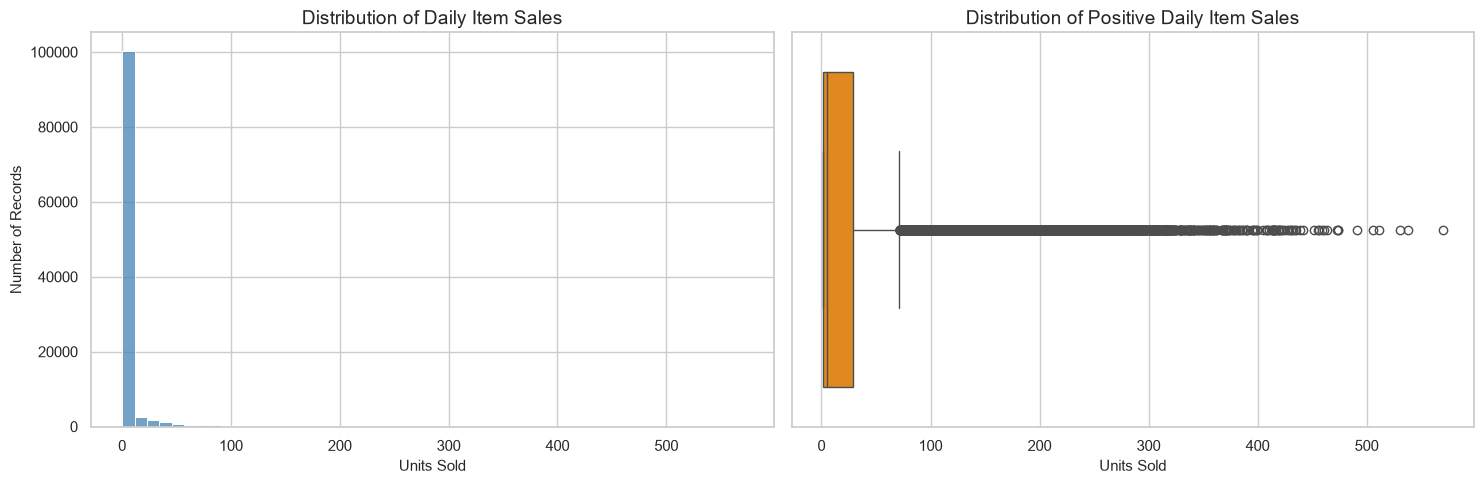

,date,restaurant_name,item_id,item_name,units_sold
53604,2020-06-20,Bob's Diner,19,Strawberry Smoothy,570.00
54204,2020-06-26,Bob's Diner,19,Strawberry Smoothy,538.00
53504,2020-06-19,Bob's Diner,19,Strawberry Smoothy,531.00
52905,2020-06-13,Bob's Diner,19,Strawberry Smoothy,511.00
54305,2020-06-27,Bob's Diner,19,Strawberry Smoothy,506.00
54104,2020-06-25,Bob's Diner,19,Strawberry Smoothy,491.00
54905,2020-07-03,Bob's Diner,19,Strawberry Smoothy,474.00
55005,2020-07-04,Bob's Diner,19,Strawberry Smoothy,474.00
53404,2020-06-18,Bob's Diner,19,Strawberry Smoothy,473.00
56305,2020-07-17,Bob's Diner,19,Strawberry Smoothy,464.00


In [16]:
# Summarize the distribution of units sold
units_sold_summary = merged_df["units_sold"].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]
).to_frame(name="Units Sold")

display(units_sold_summary)

# Calculate the percentage of item-date records with zero sales
zero_sales_percentage = (
    merged_df["units_sold"].eq(0).mean() * 100
)

print(
    f"Percentage of item-date records with zero sales: "
    f"{zero_sales_percentage:.2f}%"
)

# Separate positive sales for a clearer second visualization
positive_sales = merged_df.loc[
    merged_df["units_sold"] > 0,
    "units_sold"
]

# Visualize the complete distribution and positive-sales distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=merged_df,
    x="units_sold",
    bins=50,
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Distribution of Daily Item Sales")
axes[0].set_xlabel("Units Sold")
axes[0].set_ylabel("Number of Records")

sns.boxplot(
    x=positive_sales,
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title("Distribution of Positive Daily Item Sales")
axes[1].set_xlabel("Units Sold")

plt.tight_layout()
plt.show()

# Display the largest observed item-level sales counts
highest_sales_records = (
    merged_df.nlargest(10, "units_sold")[
        [
            "date",
            "restaurant_name",
            "item_id",
            "item_name",
            "units_sold"
        ]
    ]
)

display(highest_sales_records)

,date,total_units_sold,total_revenue,units_sold_30_day_avg
0,2019-01-01,427.00,"4,023.00",427.00
1,2019-01-02,337.00,"3,074.69",382.00
2,2019-01-03,445.00,"4,062.71",403.00
3,2019-01-04,564.00,"5,006.81",443.25
4,2019-01-05,552.00,"4,927.53",465.00


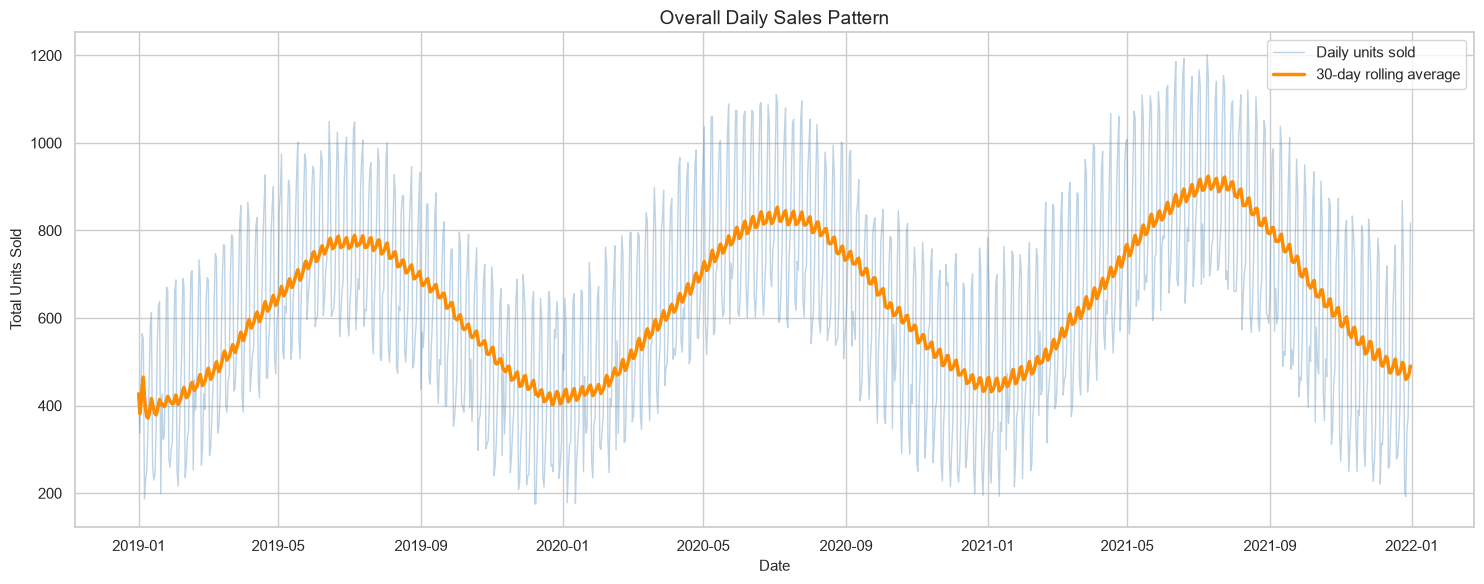

In [17]:
# Aggregate item-level records into total daily sales
daily_sales_df = (
    merged_df.groupby("date", as_index=False)
    .agg(
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum")
    )
    .sort_values("date")
)

# Calculate a rolling average to reveal the broader sales trend
daily_sales_df["units_sold_30_day_avg"] = (
    daily_sales_df["total_units_sold"]
    .rolling(window=30, min_periods=1)
    .mean()
)

display(daily_sales_df.head())

# Plot daily sales and the rolling trend
plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales_df["date"],
    daily_sales_df["total_units_sold"],
    color="steelblue",
    alpha=0.35,
    linewidth=1,
    label="Daily units sold"
)

plt.plot(
    daily_sales_df["date"],
    daily_sales_df["units_sold_30_day_avg"],
    color="darkorange",
    linewidth=2.5,
    label="30-day rolling average"
)

plt.title("Overall Daily Sales Pattern")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Sales Patterns by Weekday, Month, and Quarter

Sales are examined across different calendar periods to identify recurring seasonal patterns. Average daily sales are used for weekday and monthly comparisons so that periods containing different numbers of calendar days can be compared fairly. Quarterly totals are also calculated separately for each year and then averaged across the three-year period.


,day_name,average_daily_units,median_daily_units,standard_deviation,number_of_days
0,Monday,449.44,463.50,156.55,156
1,Tuesday,506.08,505.00,148.05,157
2,Wednesday,562.41,557.00,149.87,157
3,Thursday,744.89,752.00,154.99,157
4,Friday,868.15,860.00,153.74,157
5,Saturday,869.51,873.50,158.08,156
6,Sunday,436.10,435.00,151.82,156


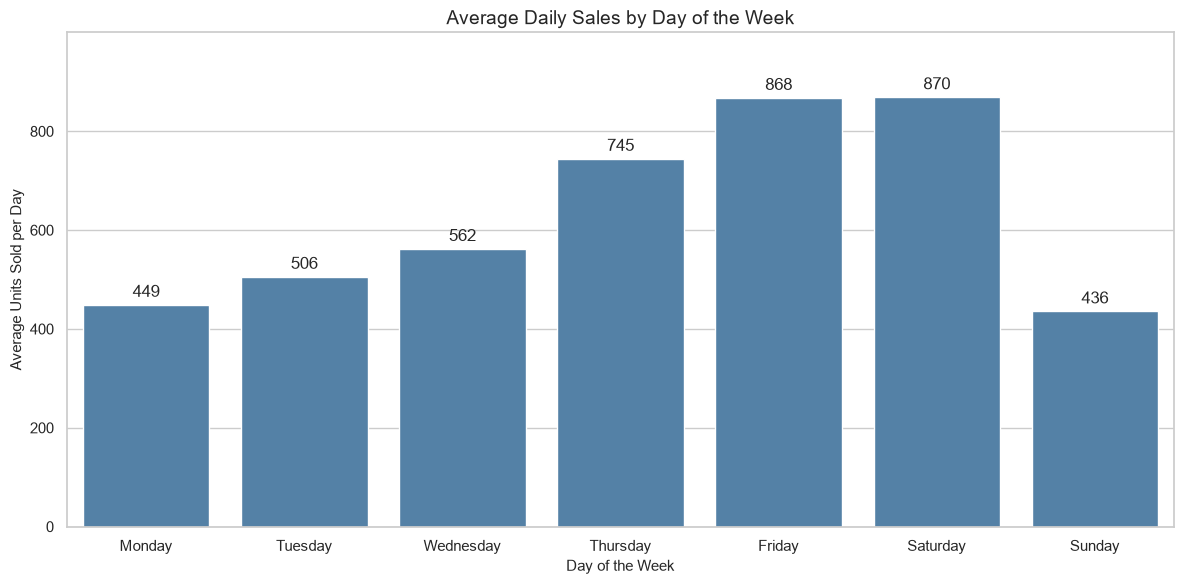

In [18]:
# Define the natural weekday order
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Add the weekday name to the daily sales summary
daily_sales_df["day_name"] = (
    daily_sales_df["date"].dt.day_name()
)

# Calculate daily-sales statistics for each weekday
weekday_sales_df = (
    daily_sales_df.groupby("day_name")["total_units_sold"]
    .agg(
        average_daily_units="mean",
        median_daily_units="median",
        standard_deviation="std",
        number_of_days="count"
    )
    .reindex(weekday_order)
    .reset_index()
)

display(weekday_sales_df.round(2))

# Visualize average sales by weekday
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=weekday_sales_df,
    x="day_name",
    y="average_daily_units",
    color="steelblue"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.0f",
    padding=3
)

plt.title("Average Daily Sales by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Units Sold per Day")
plt.ylim(
    0,
    weekday_sales_df["average_daily_units"].max() * 1.15
)
plt.tight_layout()
plt.show()

,year,2019,2020,2021
month,month_name,,,
1,January,406.23,444.35,480.71
2,February,470.86,522.79,544.68
3,March,563.03,591.68,623.90
4,April,634.47,706.97,763.40
5,May,744.23,801.23,829.77
6,June,771.80,820.23,888.73
7,July,745.84,825.77,916.29
8,August,710.71,742.32,788.97
9,September,599.97,654.33,701.03


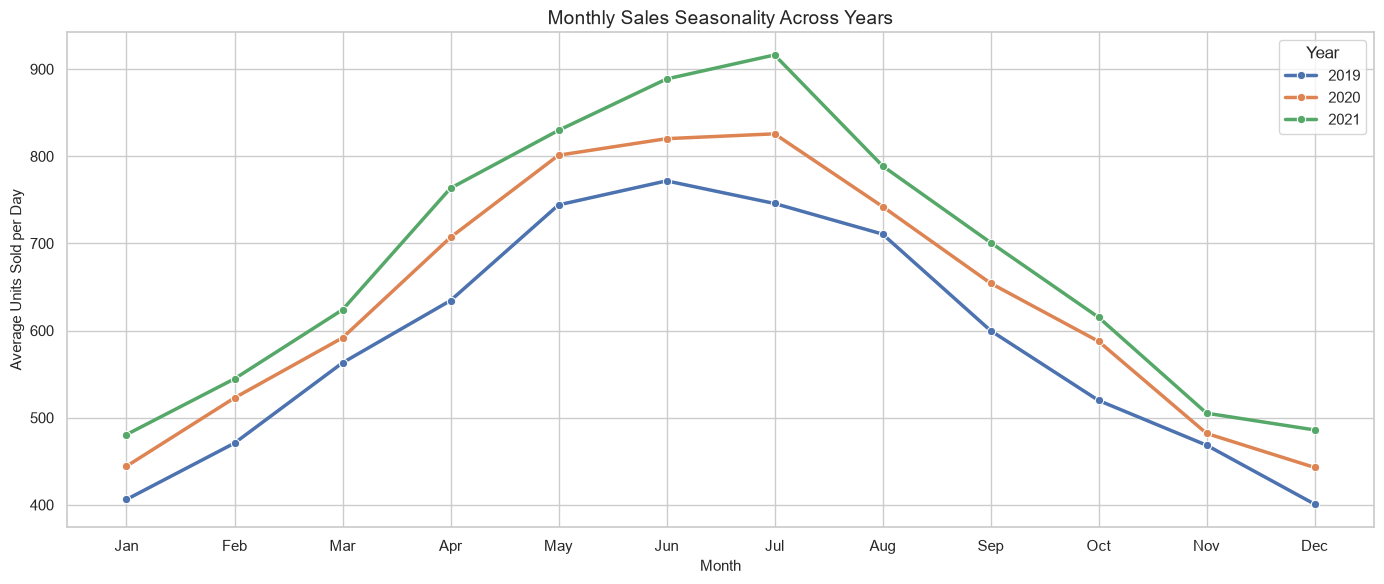

In [19]:
# Add year and month information to the daily sales summary
daily_sales_df["year"] = daily_sales_df["date"].dt.year
daily_sales_df["month"] = daily_sales_df["date"].dt.month
daily_sales_df["month_name"] = daily_sales_df["date"].dt.month_name()

# Calculate average daily sales for each month of each year
monthly_pattern_df = (
    daily_sales_df.groupby(
        ["year", "month", "month_name"],
        as_index=False
    )
    .agg(
        average_daily_units_sold=(
            "total_units_sold",
            "mean"
        )
    )
    .sort_values(["year", "month"])
)

# Create a readable comparison table
monthly_pattern_table = (
    monthly_pattern_df.pivot(
        index=["month", "month_name"],
        columns="year",
        values="average_daily_units_sold"
    )
    .round(2)
)

display(monthly_pattern_table)

# Use text labels so each year appears as a separate line
monthly_pattern_df["year_label"] = (
    monthly_pattern_df["year"].astype(str)
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_pattern_df,
    x="month",
    y="average_daily_units_sold",
    hue="year_label",
    marker="o",
    linewidth=2.5
)

plt.title("Monthly Sales Seasonality Across Years")
plt.xlabel("Month")
plt.ylabel("Average Units Sold per Day")
plt.xticks(
    ticks=range(1, 13),
    labels=[
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

,year,quarter,total_quarter_units_sold,average_daily_units_sold
0,2019,1,"43,231.00",480.34
1,2019,2,"65,259.00",717.13
2,2019,3,"63,152.00",686.43
3,2019,4,"42,595.00",462.99
4,2020,1,"47,278.00",519.54
5,2020,2,"70,654.00",776.42
6,2020,3,"68,241.00",741.75
7,2020,4,"46,408.00",504.43
8,2021,1,"49,494.00",549.93
9,2021,2,"75,287.00",827.33


,quarter,average_quarter_units_sold,average_daily_units_sold,quarter_label
0,1,"46,667.67",516.61,Q1
1,2,"70,400.00",773.63,Q2
2,3,"68,429.00",743.79,Q3
3,4,"46,099.00",501.08,Q4


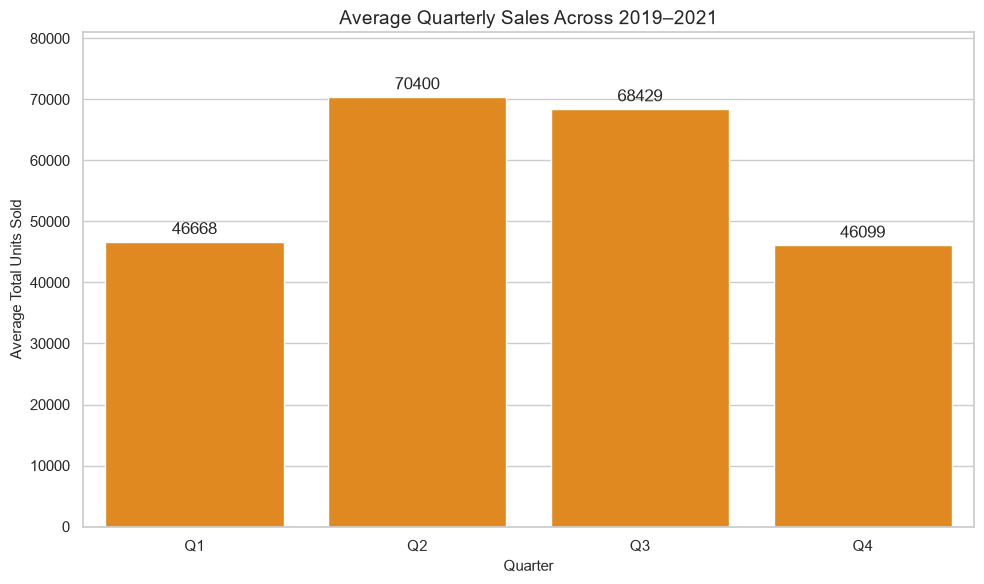

In [20]:
# Add quarter information to the daily sales summary
daily_sales_df["quarter"] = (
    daily_sales_df["date"].dt.quarter
)

# Calculate quarterly results separately for each year
quarterly_by_year_df = (
    daily_sales_df.groupby(
        ["year", "quarter"],
        as_index=False
    )
    .agg(
        total_quarter_units_sold=(
            "total_units_sold",
            "sum"
        ),
        average_daily_units_sold=(
            "total_units_sold",
            "mean"
        )
    )
)

# Average each quarter's results across the three years
quarterly_summary_df = (
    quarterly_by_year_df.groupby(
        "quarter",
        as_index=False
    )
    .agg(
        average_quarter_units_sold=(
            "total_quarter_units_sold",
            "mean"
        ),
        average_daily_units_sold=(
            "average_daily_units_sold",
            "mean"
        )
    )
)

quarterly_summary_df["quarter_label"] = (
    "Q" + quarterly_summary_df["quarter"].astype(str)
)

display(quarterly_by_year_df)
display(quarterly_summary_df.round(2))

# Visualize average quarterly sales
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=quarterly_summary_df,
    x="quarter_label",
    y="average_quarter_units_sold",
    color="darkorange"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.0f",
    padding=3
)

plt.title("Average Quarterly Sales Across 2019–2021")
plt.xlabel("Quarter")
plt.ylabel("Average Total Units Sold")
plt.ylim(
    0,
    quarterly_summary_df[
        "average_quarter_units_sold"
    ].max() * 1.15
)
plt.tight_layout()
plt.show()

### 5.3 Restaurant Performance

Restaurant performance is compared using total units sold, average daily units sold, total revenue, and average daily revenue. Sales are first aggregated to the restaurant-date level so that each restaurant receives equal weight when calculating daily averages.

Performance is then examined across years, months, and days of the week. Where large differences in restaurant sales volume make direct visualization difficult, logarithmic or normalized scales are used while the accompanying tables retain the original sales values.


In [21]:
# Aggregate sales to one record per restaurant per date
restaurant_daily_df = (
    merged_df.groupby(
        [
            "date",
            "restaurant_id",
            "restaurant_name"
        ],
        as_index=False
    )
    .agg(
        daily_units_sold=("units_sold", "sum"),
        daily_revenue=("revenue", "sum")
    )
    .sort_values(
        ["restaurant_name", "date"]
    )
)

# Add calendar fields for later comparisons
restaurant_daily_df["year"] = (
    restaurant_daily_df["date"].dt.year
)

restaurant_daily_df["month"] = (
    restaurant_daily_df["date"].dt.month
)

restaurant_daily_df["day_name"] = (
    restaurant_daily_df["date"].dt.day_name()
)

# Summarize overall restaurant performance
restaurant_performance_df = (
    restaurant_daily_df.groupby(
        [
            "restaurant_id",
            "restaurant_name"
        ],
        as_index=False
    )
    .agg(
        total_units_sold=(
            "daily_units_sold",
            "sum"
        ),
        average_daily_units_sold=(
            "daily_units_sold",
            "mean"
        ),
        total_revenue=(
            "daily_revenue",
            "sum"
        ),
        average_daily_revenue=(
            "daily_revenue",
            "mean"
        )
    )
    .sort_values(
        "total_units_sold",
        ascending=False
    )
)

display(restaurant_performance_df.round(2))

# Identify the leaders in sales volume and daily revenue
highest_sales_restaurant = restaurant_performance_df.loc[
    restaurant_performance_df["total_units_sold"].idxmax(),
    "restaurant_name"
]

highest_revenue_restaurant = restaurant_performance_df.loc[
    restaurant_performance_df["average_daily_revenue"].idxmax(),
    "restaurant_name"
]

print(
    f"Restaurant with the highest sales volume: "
    f"{highest_sales_restaurant}"
)

print(
    f"Restaurant with the highest average daily revenue: "
    f"{highest_revenue_restaurant}"
)

if highest_sales_restaurant == highest_revenue_restaurant:
    print(
        "The highest-volume restaurant also produces "
        "the most revenue per day."
    )
else:
    print(
        "The highest-volume restaurant does not produce "
        "the most revenue per day."
    )

,restaurant_id,restaurant_name,total_units_sold,average_daily_units_sold,total_revenue,average_daily_revenue
0,1,Bob's Diner,"687,527.00",627.31,"6,337,275.69","5,782.19"
5,6,Surfs Up,"1,803.00",1.65,"15,651.49",14.28
2,3,Sweet Shack,"1,736.00",1.58,"2,578.27",2.35
4,5,Corner Cafe,"1,310.00",1.20,"16,551.43",15.10
1,2,Beachfront Bar,"1,305.00",1.19,"3,796.20",3.46
3,4,Fou Cher,"1,106.00",1.01,"27,885.37",25.44


Restaurant with the highest sales volume: Bob's Diner
Restaurant with the highest average daily revenue: Bob's Diner
The highest-volume restaurant also produces the most revenue per day.


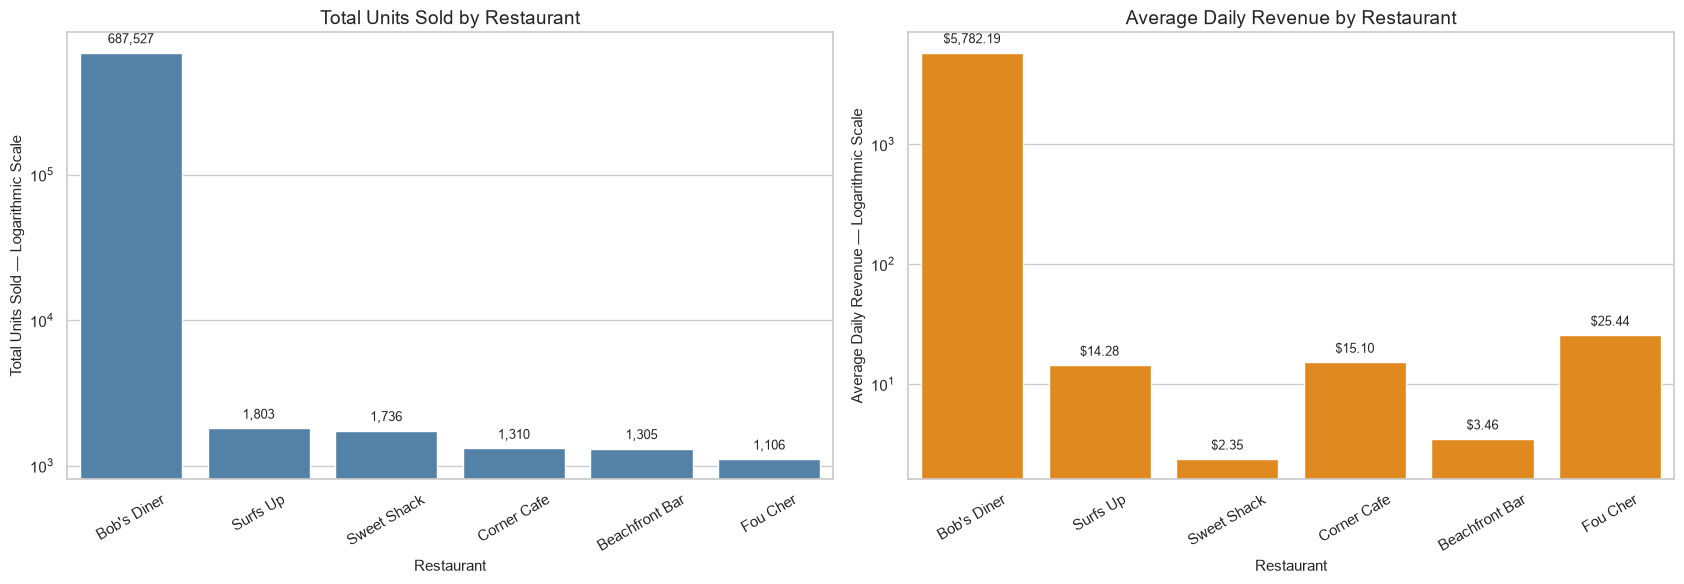

In [22]:
# Preserve the performance ranking in the charts
restaurant_order = (
    restaurant_performance_df["restaurant_name"].tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Total units sold
sns.barplot(
    data=restaurant_performance_df,
    x="restaurant_name",
    y="total_units_sold",
    order=restaurant_order,
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Total Units Sold by Restaurant")
axes[0].set_xlabel("Restaurant")
axes[0].set_ylabel("Total Units Sold — Logarithmic Scale")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=30)

# Add labels without using ax.containers
for bar in axes[0].patches:
    height = bar.get_height()

    axes[0].annotate(
        f"{height:,.0f}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            height
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Average daily revenue
sns.barplot(
    data=restaurant_performance_df,
    x="restaurant_name",
    y="average_daily_revenue",
    order=restaurant_order,
    color="darkorange",
    ax=axes[1]
)

axes[1].set_title("Average Daily Revenue by Restaurant")
axes[1].set_xlabel("Restaurant")
axes[1].set_ylabel("Average Daily Revenue — Logarithmic Scale")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=30)

for bar in axes[1].patches:
    height = bar.get_height()

    axes[1].annotate(
        f"${height:,.2f}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            height
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

year,2019,2020,2021
restaurant_name,,,
Bob's Diner,"211,799.00","230,191.00","245,537.00"
Surfs Up,594.00,627.00,582.00
Sweet Shack,590.00,554.00,592.00
Corner Cafe,423.00,415.00,472.00
Beachfront Bar,439.00,437.00,429.00
Fou Cher,392.00,357.00,357.00


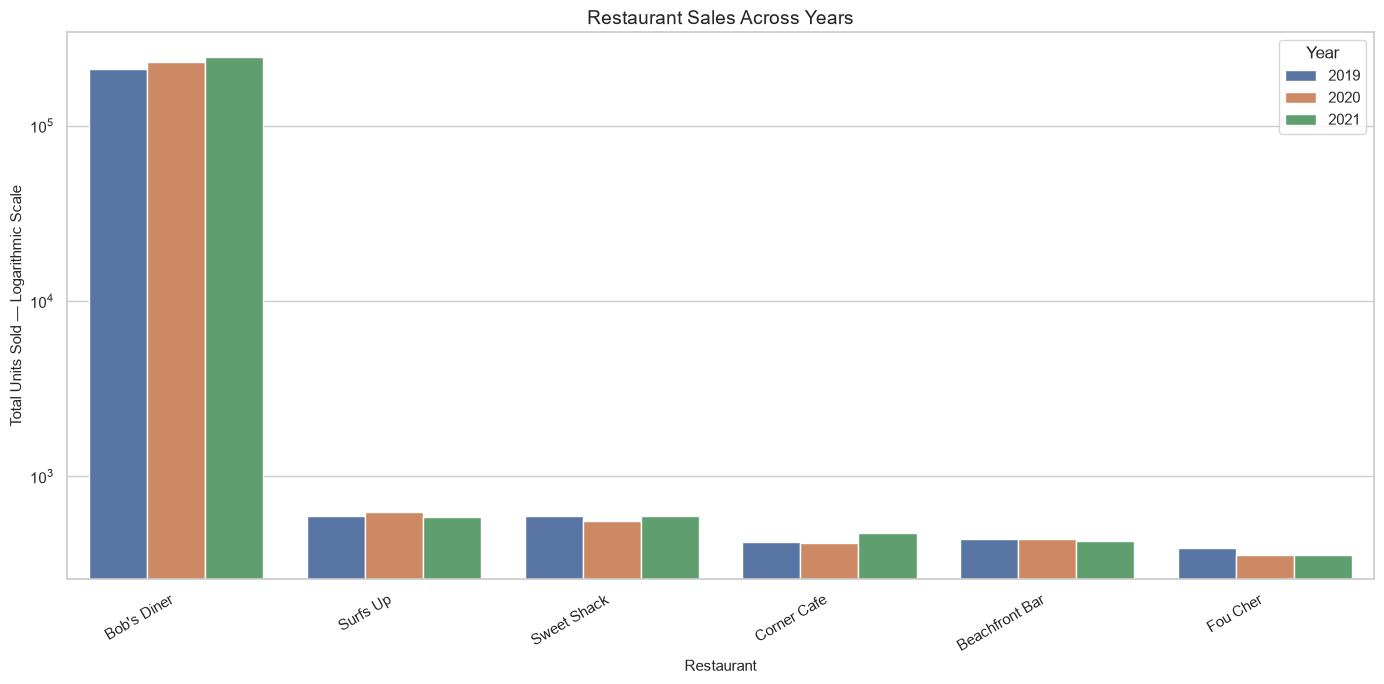

In [23]:
# Calculate total annual sales for each restaurant
restaurant_yearly_df = (
    restaurant_daily_df.groupby(
        ["restaurant_name", "year"],
        as_index=False
    )
    .agg(
        total_units_sold=(
            "daily_units_sold",
            "sum"
        )
    )
)

restaurant_yearly_table = (
    restaurant_yearly_df.pivot(
        index="restaurant_name",
        columns="year",
        values="total_units_sold"
    )
    .reindex(restaurant_order)
)

display(restaurant_yearly_table.round(0))

# Treat year as a categorical chart label
restaurant_yearly_df["year_label"] = (
    restaurant_yearly_df["year"].astype(str)
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=restaurant_yearly_df,
    x="restaurant_name",
    y="total_units_sold",
    hue="year_label",
    order=restaurant_order
)

plt.yscale("log")
plt.title("Restaurant Sales Across Years")
plt.xlabel("Restaurant")
plt.ylabel("Total Units Sold — Logarithmic Scale")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [24]:
# Calculate average daily sales by restaurant and month
restaurant_monthly_df = (
    restaurant_daily_df.groupby(
        ["restaurant_name", "month"],
        as_index=False
    )
    .agg(
        average_daily_units_sold=(
            "daily_units_sold",
            "mean"
        )
    )
)

# Create a raw-value comparison table
restaurant_monthly_table = (
    restaurant_monthly_df.pivot(
        index="restaurant_name",
        columns="month",
        values="average_daily_units_sold"
    )
    .reindex(restaurant_order)
)

restaurant_monthly_table.columns = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

display(restaurant_monthly_table.round(2))

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
restaurant_name,,,,,,,,,,,,
Bob's Diner,437.33,505.95,586.13,695.17,784.82,820.40,822.88,741.05,645.16,567.44,478.72,436.38
Surfs Up,1.42,2.00,1.67,1.62,1.68,1.53,1.73,1.74,1.59,1.72,1.57,1.49
Sweet Shack,1.81,1.51,1.61,1.44,1.70,1.64,1.52,1.42,1.71,1.59,1.46,1.59
Corner Cafe,0.88,1.31,1.17,1.14,1.15,1.32,1.19,1.22,1.24,1.33,1.21,1.18
Beachfront Bar,1.15,1.28,1.26,1.21,1.22,1.09,1.11,1.06,1.18,1.09,1.20,1.45
Fou Cher,1.17,0.85,1.03,1.02,1.18,0.93,0.87,0.84,0.90,1.05,1.07,1.17


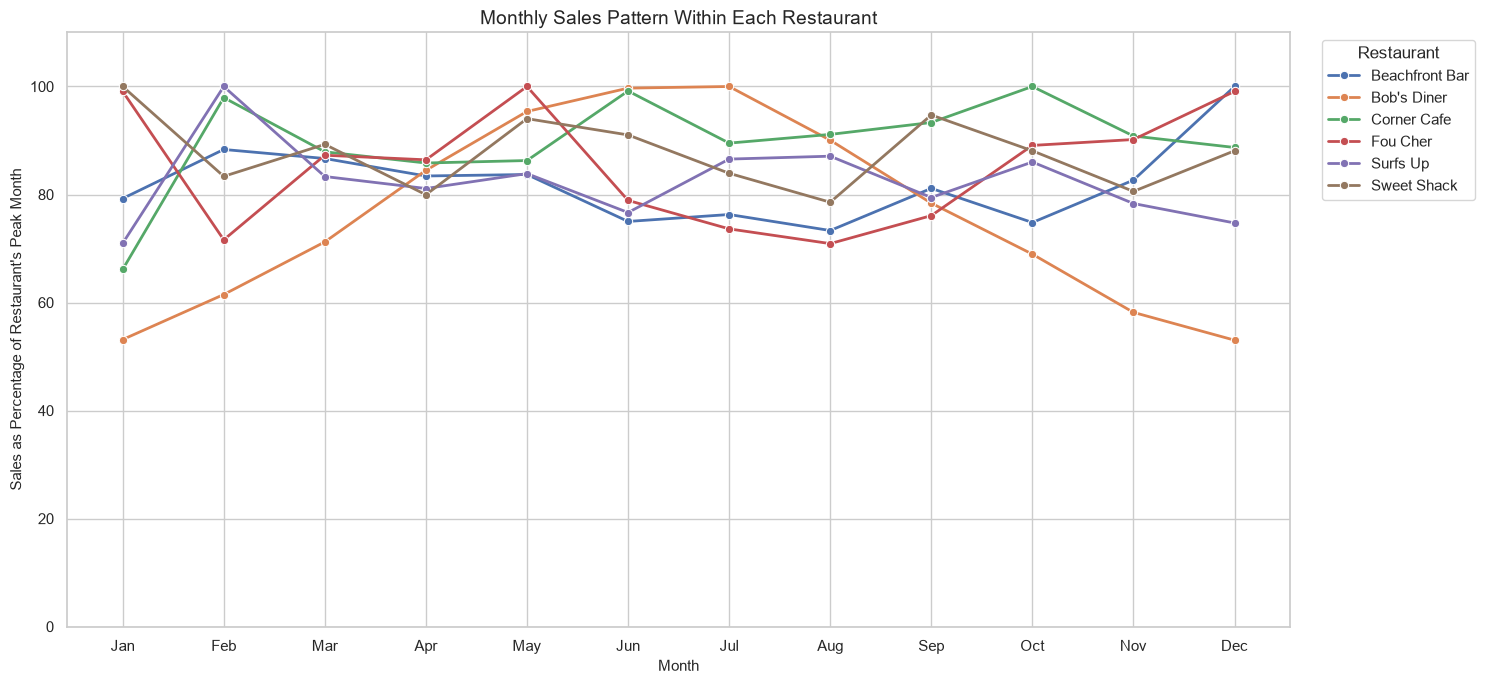

In [25]:
# Express each month as a percentage of that restaurant's peak month
restaurant_monthly_df["percent_of_peak_month"] = (
    restaurant_monthly_df[
        "average_daily_units_sold"
    ]
    / restaurant_monthly_df.groupby(
        "restaurant_name"
    )["average_daily_units_sold"].transform("max")
    * 100
)

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=restaurant_monthly_df,
    x="month",
    y="percent_of_peak_month",
    hue="restaurant_name",
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Pattern Within Each Restaurant")
plt.xlabel("Month")
plt.ylabel("Sales as Percentage of Restaurant's Peak Month")
plt.xticks(
    ticks=range(1, 13),
    labels=[
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)
plt.ylim(0, 110)
plt.legend(title="Restaurant", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

day_name,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
restaurant_name,,,,,,,
Bob's Diner,442.86,499.39,555.89,738.36,861.39,862.83,429.49
Surfs Up,1.64,1.55,1.58,1.62,1.84,1.65,1.63
Sweet Shack,1.56,1.75,1.45,1.57,1.51,1.69,1.55
Corner Cafe,1.17,1.27,1.08,1.17,1.23,1.16,1.28
Beachfront Bar,1.21,1.20,1.32,1.15,1.12,1.19,1.15
Fou Cher,0.99,0.91,1.09,1.03,1.06,0.98,1.00


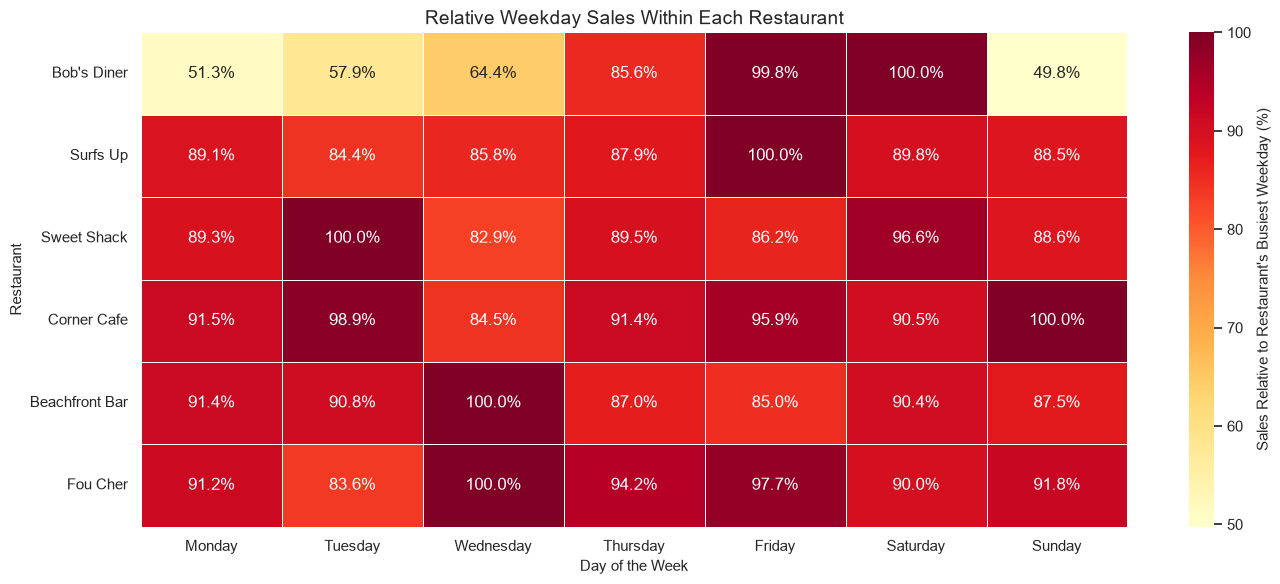

In [26]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate average daily sales for every restaurant and weekday
restaurant_weekday_df = (
    restaurant_daily_df.groupby(
        ["restaurant_name", "day_name"],
        as_index=False
    )
    .agg(
        average_daily_units_sold=(
            "daily_units_sold",
            "mean"
        )
    )
)

restaurant_weekday_table = (
    restaurant_weekday_df.pivot(
        index="restaurant_name",
        columns="day_name",
        values="average_daily_units_sold"
    )
    .reindex(
        index=restaurant_order,
        columns=weekday_order
    )
)

display(restaurant_weekday_table.round(2))

# Express each weekday as a percentage of that restaurant's busiest weekday
restaurant_weekday_percent = (
    restaurant_weekday_table.div(
        restaurant_weekday_table.max(axis=1),
        axis=0
    )
    * 100
)

# Create percentage labels for the heatmap cells
weekday_heatmap_labels = np.array([
    [f"{value:.1f}%" for value in row]
    for row in restaurant_weekday_percent.to_numpy()
])

plt.figure(figsize=(14, 6))

sns.heatmap(
    restaurant_weekday_percent,
    annot=weekday_heatmap_labels,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.5,
    vmin=restaurant_weekday_percent.min().min(),
    vmax=100,
    cbar_kws={
        "label": "Sales Relative to Restaurant's Busiest Weekday (%)"
    }
)

plt.title("Relative Weekday Sales Within Each Restaurant")
plt.xlabel("Day of the Week")
plt.ylabel("Restaurant")
plt.tight_layout()
plt.show()

### 5.4 Item-Level Performance

Item performance is evaluated using total units sold across the complete three-year period. The most popular items overall are identified along with the restaurants where they are sold. The leading item within each restaurant is also examined.

Finally, the most expensive item offered by each restaurant is identified using its unit cost, together with its calorie count.

In [27]:
# Calculate total sales for every item
item_sales_df = (
    merged_df.groupby(
        [
            "item_id",
            "item_name",
            "restaurant_id",
            "restaurant_name"
        ],
        as_index=False
    )
    .agg(
        total_units_sold=("units_sold", "sum")
    )
    .sort_values(
        "total_units_sold",
        ascending=False
    )
)

# Display the ten most popular items overall
top_10_items_df = item_sales_df.head(10).copy()

display(
    top_10_items_df[
        [
            "item_id",
            "item_name",
            "restaurant_name",
            "total_units_sold"
        ]
    ]
)

,item_id,item_name,restaurant_name,total_units_sold
18,19,Strawberry Smoothy,Bob's Diner,"236,337.00"
15,16,Frozen Milky Smoothy,Bob's Diner,"102,990.00"
75,76,Amazing pork lunch,Bob's Diner,"61,043.00"
37,38,Mutton Dinner,Bob's Diner,"52,772.00"
8,9,Orange Juice,Bob's Diner,"43,874.00"
58,59,Blue Ribbon Beef Entree,Bob's Diner,"42,774.00"
3,4,Amazing Steak Dinner with Rolls,Bob's Diner,"34,439.00"
12,13,Sweet Frozen Soft Drink,Bob's Diner,"27,490.00"
55,56,Sea Bass with Vegetables Dinner,Bob's Diner,"23,839.00"
66,67,Sweet Lamb Cake,Bob's Diner,"18,764.00"


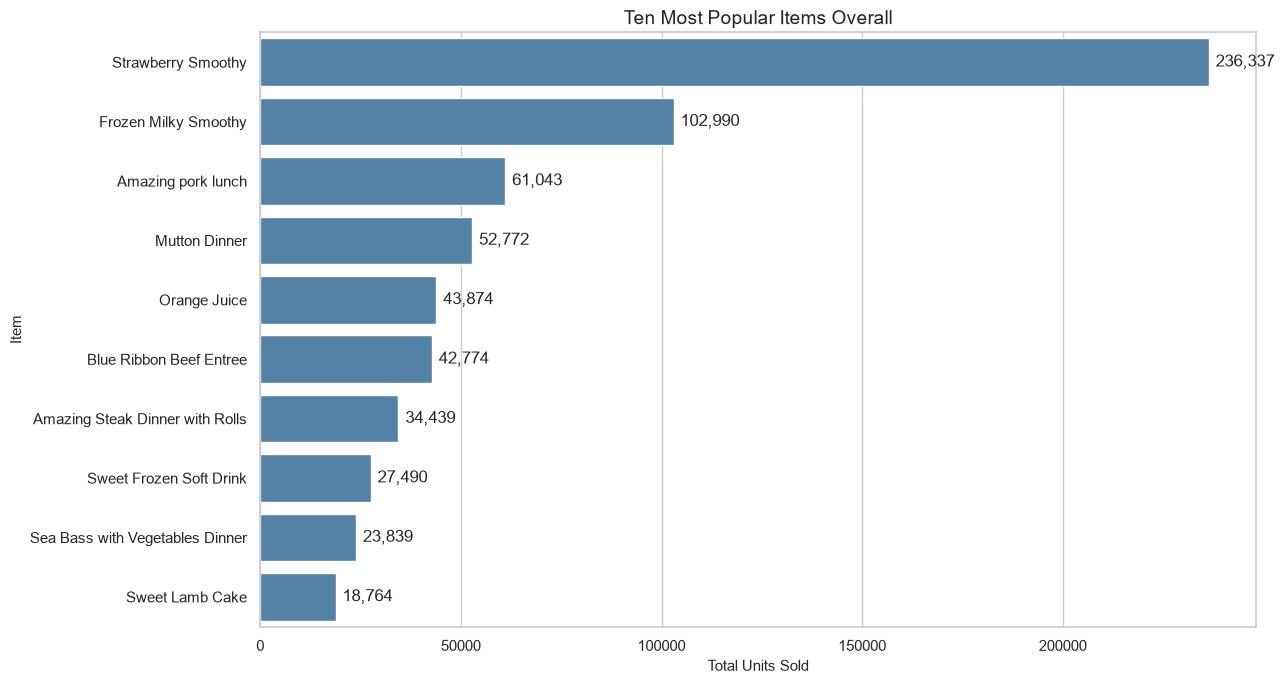

In [28]:
plt.figure(figsize=(13, 7))

ax = sns.barplot(
    data=top_10_items_df,
    x="total_units_sold",
    y="item_name",
    color="steelblue"
)

plt.title("Ten Most Popular Items Overall")
plt.xlabel("Total Units Sold")
plt.ylabel("Item")

for bar in ax.patches:
    width = bar.get_width()

    ax.annotate(
        f"{width:,.0f}",
        xy=(
            width,
            bar.get_y() + bar.get_height() / 2
        ),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center"
    )

plt.tight_layout()
plt.show()

In [29]:
# Locate the highest-selling item within each restaurant
top_item_indices = (
    item_sales_df.groupby("restaurant_id")[
        "total_units_sold"
    ].idxmax()
)

top_item_by_restaurant_df = (
    item_sales_df.loc[
        top_item_indices,
        [
            "restaurant_name",
            "item_id",
            "item_name",
            "total_units_sold"
        ]
    ]
    .sort_values(
        "total_units_sold",
        ascending=False
    )
    .reset_index(drop=True)
)

display(top_item_by_restaurant_df)

,restaurant_name,item_id,item_name,total_units_sold
0,Bob's Diner,19,Strawberry Smoothy,"236,337.00"
1,Sweet Shack,49,Awesome Smoothy,"1,692.00"
2,Beachfront Bar,42,Fantastic Milky Smoothy,"1,147.00"
3,Surfs Up,89,Awesome Soft Drink,997.00
4,Fou Cher,80,Blue Ribbon Fruity Vegi Lunch,298.00
5,Corner Cafe,71,Frozen Milky Smoothy,273.00


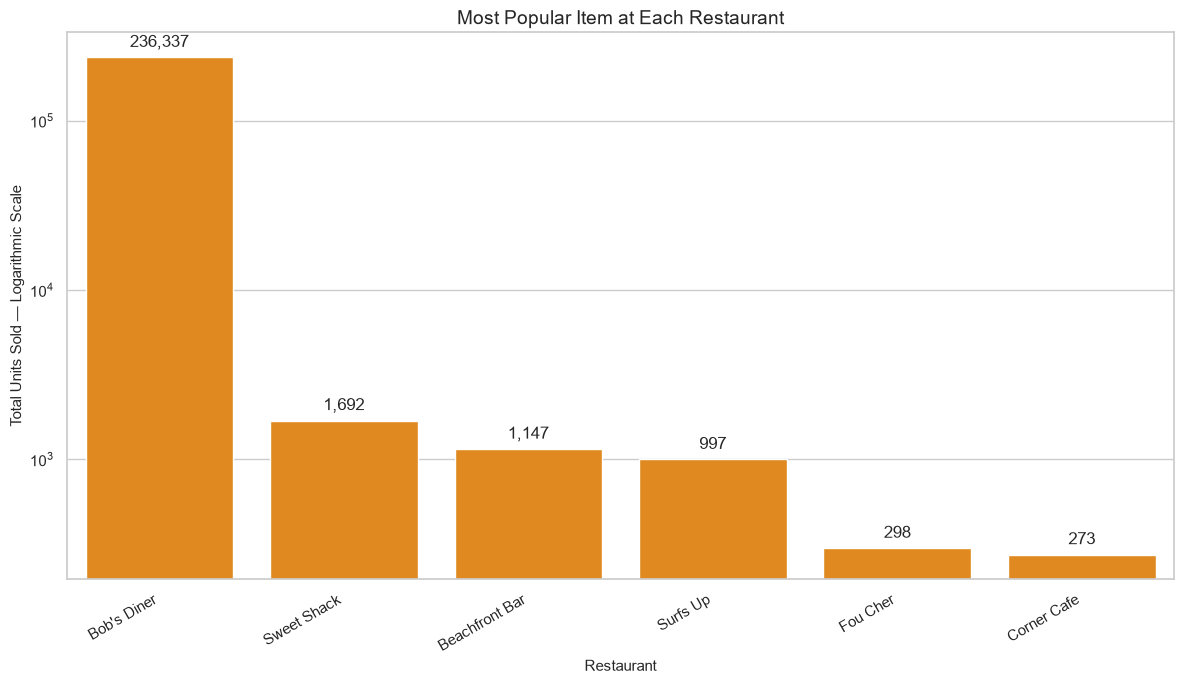

In [30]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_item_by_restaurant_df,
    x="restaurant_name",
    y="total_units_sold",
    color="darkorange"
)

plt.yscale("log")
plt.title("Most Popular Item at Each Restaurant")
plt.xlabel("Restaurant")
plt.ylabel("Total Units Sold — Logarithmic Scale")
plt.xticks(rotation=30, ha="right")

for bar in ax.patches:
    height = bar.get_height()

    ax.annotate(
        f"{height:,.0f}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            height
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [31]:
# Keep one record for each item
item_details_df = (
    merged_df[
        [
            "restaurant_id",
            "restaurant_name",
            "item_id",
            "item_name",
            "item_cost",
            "calories"
        ]
    ]
    .drop_duplicates()
)

# Locate the highest-cost item within each restaurant
most_expensive_indices = (
    item_details_df.groupby("restaurant_id")[
        "item_cost"
    ].idxmax()
)

most_expensive_items_df = (
    item_details_df.loc[
        most_expensive_indices,
        [
            "restaurant_name",
            "item_id",
            "item_name",
            "item_cost",
            "calories"
        ]
    ]
    .sort_values(
        "item_cost",
        ascending=False
    )
    .reset_index(drop=True)
)

display(most_expensive_items_df)

,restaurant_name,item_id,item_name,item_cost,calories
0,Fou Cher,80,Blue Ribbon Fruity Vegi Lunch,53.98,881
1,Bob's Diner,3,Sweet Fruity Cake,29.22,931
2,Corner Cafe,50,Pike Lunch,26.37,653
3,Surfs Up,27,Steak Meal,26.21,607
4,Sweet Shack,77,Blue Ribbon Frozen Milky Cake,7.70,636
5,Beachfront Bar,62,Sweet Vegi Soft Drink,5.70,538


## 6. Forecasting Model Development

The objective of the modeling stage is to predict the number of units sold for each item on each date. Linear regression, random forest regression, and XGBoost regression models will be developed and compared.

Because the observations are time-dependent, a random train-test split is not appropriate. Data prior to July 1, 2021, will be used for training, while the final six months of 2021 will be reserved for testing. This chronological split simulates predicting future sales from information available at an earlier date.


In [32]:
# Reserve the final six months of 2021 for model testing
test_start_date = pd.Timestamp("2021-07-01")

train_df = merged_df.loc[
    merged_df["date"] < test_start_date
].copy()

test_df = merged_df.loc[
    merged_df["date"] >= test_start_date
].copy()

In [33]:
# Confirm that the test period occurs entirely after training
assert train_df["date"].max() < test_df["date"].min()

print("Training period:", train_df["date"].min(), "to", train_df["date"].max())
print("Testing period: ", test_df["date"].min(), "to", test_df["date"].max())

print(f"\nTraining rows: {len(train_df):,}")
print(f"Testing rows:  {len(test_df):,}")

print(f"\nTraining share: {len(train_df) / len(merged_df):.2%}")
print(f"Testing share:  {len(test_df) / len(merged_df):.2%}")

Training period: 2019-01-01 00:00:00 to 2021-06-30 00:00:00
Testing period:  2021-07-01 00:00:00 to 2021-12-31 00:00:00

Training rows: 91,200
Testing rows:  18,400

Training share: 83.21%
Testing share:  16.79%


### 6.1 Feature and Target Preparation

The target variable is `units_sold`, representing the number of units of an item sold on a particular date. Calendar features are used to capture weekly, monthly, quarterly, and annual sales patterns.

The item and restaurant identifiers are treated as categorical variables rather than continuous numbers. One-hot encoding is used so that the models do not incorrectly interpret higher identification numbers as larger numerical values.

The `revenue` field is excluded because it was calculated using `units_sold` and would cause target leakage. The raw date, descriptive names, and duplicate price information are also excluded from model training.


In [34]:
# Treat item and restaurant identifiers as categorical features
categorical_features = [
    "item_id",
    "restaurant_id"
]

# Use calendar and cyclical fields as numerical features
numeric_features = [
    "year",
    "quarter",
    "month",
    "day_of_month",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

model_features = (
    categorical_features
    + numeric_features
)

# Verify that every required feature exists
missing_features = [
    column
    for column in model_features
    if column not in merged_df.columns
]

assert not missing_features, (
    f"Missing model features: {missing_features}"
)

# Verify that leakage columns were not selected
leakage_columns = {
    "units_sold",
    "revenue"
}.intersection(model_features)

assert not leakage_columns, (
    f"Target leakage detected: {leakage_columns}"
)

# Create the training and testing feature matrices
X_train = train_df[model_features].copy()
X_test = test_df[model_features].copy()

# Create the training and testing targets
y_train = train_df["units_sold"].copy()
y_test = test_df["units_sold"].copy()

# Convert identifier columns to strings so they are categorical
for column in categorical_features:
    X_train[column] = X_train[column].astype(str)
    X_test[column] = X_test[column].astype(str)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (91200, 16)
X_test shape:  (18400, 16)
y_train shape: (91200,)
y_test shape:  (18400,)


In [35]:
# Confirm that the feature and target rows align
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

# Confirm that no feature values are missing
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

# Confirm that training and testing contain the same columns
assert X_train.columns.equals(X_test.columns)

print("Training target summary:")
display(y_train.describe().round(2))

print("\nTesting target summary:")
display(y_test.describe().round(2))

print("\nModel features:")
display(
    pd.DataFrame({
        "feature": model_features,
        "feature_type": [
            "Categorical"
            if feature in categorical_features
            else "Numerical"
            for feature in model_features
        ]
    })
)

print("\nAll feature-integrity checks passed.")

Training target summary:


count   91,200.00
mean         6.27
std         29.83
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        570.00
Name: units_sold, dtype: float64


Testing target summary:


count   18,400.00
mean         6.70
std         30.85
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        442.00
Name: units_sold, dtype: float64


Model features:


,feature,feature_type
0,item_id,Categorical
1,restaurant_id,Categorical
2,year,Numerical
3,quarter,Numerical
4,month,Numerical
5,day_of_month,Numerical
6,day_of_week,Numerical
7,week_of_year,Numerical
8,is_weekend,Numerical
9,day_of_year,Numerical



All feature-integrity checks passed.


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# Scale the numerical fields
numeric_preprocessor = StandardScaler()

# One-hot encode item and restaurant identifiers
categorical_preprocessor = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# Combine both preprocessing operations
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_preprocessor,
            numeric_features
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_features
        )
    ],
    remainder="drop"
)

# Fit preprocessing only on the training data
X_train_processed = preprocessor.fit_transform(
    X_train
)

# Apply the learned transformations to testing data
X_test_processed = preprocessor.transform(
    X_test
)

# Retrieve readable names for the processed columns
processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape: ",
    X_test_processed.shape
)

print(
    "Number of processed features:",
    len(processed_feature_names)
)

print("\nFirst 20 processed feature names:")
display(
    pd.Series(
        processed_feature_names[:20],
        name="processed_feature"
    )
)

Processed training shape: (91200, 120)
Processed testing shape:  (18400, 120)
Number of processed features: 120

First 20 processed feature names:


0                numeric__year
1             numeric__quarter
2               numeric__month
3        numeric__day_of_month
4         numeric__day_of_week
5        numeric__week_of_year
6          numeric__is_weekend
7         numeric__day_of_year
8           numeric__month_sin
9           numeric__month_cos
10    numeric__day_of_week_sin
11    numeric__day_of_week_cos
12    numeric__day_of_year_sin
13    numeric__day_of_year_cos
14      categorical__item_id_1
15     categorical__item_id_10
16    categorical__item_id_100
17     categorical__item_id_11
18     categorical__item_id_12
19     categorical__item_id_13
Name: processed_feature, dtype: str

### 6.2 Linear Regression

Linear regression is used as the baseline forecasting model. The model is trained using sales observations before July 1, 2021, and evaluated using the final six months of 2021.

Model performance is primarily evaluated using root mean squared error (RMSE), as required by the project instructions. Mean absolute error (MAE) and the coefficient of determination (R²) are also reported to provide additional context.

In [37]:
from sklearn.linear_model import LinearRegression
from time import perf_counter

# Create the Linear Regression model
lr_sales_model = LinearRegression()

# Train the model using only the training period
lr_training_start = perf_counter()

lr_sales_model.fit(
    X_train_processed,
    y_train
)

lr_training_seconds = (
    perf_counter() - lr_training_start
)

# Generate predictions for the final six months
lr_prediction_start = perf_counter()

lr_sales_predictions = lr_sales_model.predict(
    X_test_processed
)

lr_prediction_seconds = (
    perf_counter() - lr_prediction_start
)

print("Linear Regression training complete.")
print(
    f"Training time: {lr_training_seconds:.3f} seconds"
)
print(
    f"Prediction time: {lr_prediction_seconds:.3f} seconds"
)

Linear Regression training complete.
Training time: 0.068 seconds
Prediction time: 0.001 seconds


In [38]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Calculate model performance metrics
lr_sales_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_sales_predictions
    )
)

lr_sales_mae = mean_absolute_error(
    y_test,
    lr_sales_predictions
)

lr_sales_r2 = r2_score(
    y_test,
    lr_sales_predictions
)

# Count predictions below zero
lr_negative_prediction_count = int(
    (lr_sales_predictions < 0).sum()
)

# Store the results separately for later comparison
lr_sales_results_df = pd.DataFrame({
    "Model": ["Linear Regression"],
    "RMSE": [lr_sales_rmse],
    "MAE": [lr_sales_mae],
    "R2": [lr_sales_r2],
    "Training Time (Seconds)": [
        lr_training_seconds
    ],
    "Prediction Time (Seconds)": [
        lr_prediction_seconds
    ],
    "Negative Predictions": [
        lr_negative_prediction_count
    ]
})

display(
    lr_sales_results_df.round({
        "RMSE": 3,
        "MAE": 3,
        "R2": 4,
        "Training Time (Seconds)": 3,
        "Prediction Time (Seconds)": 3
    })
)

,Model,RMSE,MAE,R2,Training Time (Seconds),Prediction Time (Seconds),Negative Predictions
0,Linear Regression,18.43,5.62,0.64,0.07,0.00,5915


### 6.3 Random Forest Regression

Random forest regression is used as a nonlinear ensemble model capable of capturing complex interactions between item identity, restaurant identity, and calendar-based sales patterns.

The model combines predictions from multiple decision trees. Tree depth and leaf size are constrained to reduce overfitting, while a fixed random state ensures reproducible results. Performance is evaluated on the same final six-month testing period used for linear regression.


In [39]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest Regression model
rf_sales_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    min_samples_leaf=2,
    max_features=0.7,
    random_state=123,
    n_jobs=-1
)

# Train the model using the chronological training period
rf_training_start = perf_counter()

rf_sales_model.fit(
    X_train_processed,
    y_train
)

rf_training_seconds = (
    perf_counter() - rf_training_start
)

# Generate predictions for the final six months
rf_prediction_start = perf_counter()

rf_sales_predictions = rf_sales_model.predict(
    X_test_processed
)

rf_prediction_seconds = (
    perf_counter() - rf_prediction_start
)

print("Random Forest Regression training complete.")

print(
    f"Training time: {rf_training_seconds:.3f} seconds"
)

print(
    f"Prediction time: {rf_prediction_seconds:.3f} seconds"
)

Random Forest Regression training complete.
Training time: 23.248 seconds
Prediction time: 0.050 seconds


In [40]:
# Calculate Random Forest performance metrics
rf_sales_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_sales_predictions
    )
)

rf_sales_mae = mean_absolute_error(
    y_test,
    rf_sales_predictions
)

rf_sales_r2 = r2_score(
    y_test,
    rf_sales_predictions
)

# Count impossible negative predictions
rf_negative_prediction_count = int(
    (rf_sales_predictions < 0).sum()
)

# Store results separately for later comparison
rf_sales_results_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "RMSE": [rf_sales_rmse],
    "MAE": [rf_sales_mae],
    "R2": [rf_sales_r2],
    "Training Time (Seconds)": [
        rf_training_seconds
    ],
    "Prediction Time (Seconds)": [
        rf_prediction_seconds
    ],
    "Negative Predictions": [
        rf_negative_prediction_count
    ]
})

display(
    rf_sales_results_df.round({
        "RMSE": 3,
        "MAE": 3,
        "R2": 4,
        "Training Time (Seconds)": 3,
        "Prediction Time (Seconds)": 3
    })
)

,Model,RMSE,MAE,R2,Training Time (Seconds),Prediction Time (Seconds),Negative Predictions
0,Random Forest,4.74,1.18,0.98,23.25,0.05,0


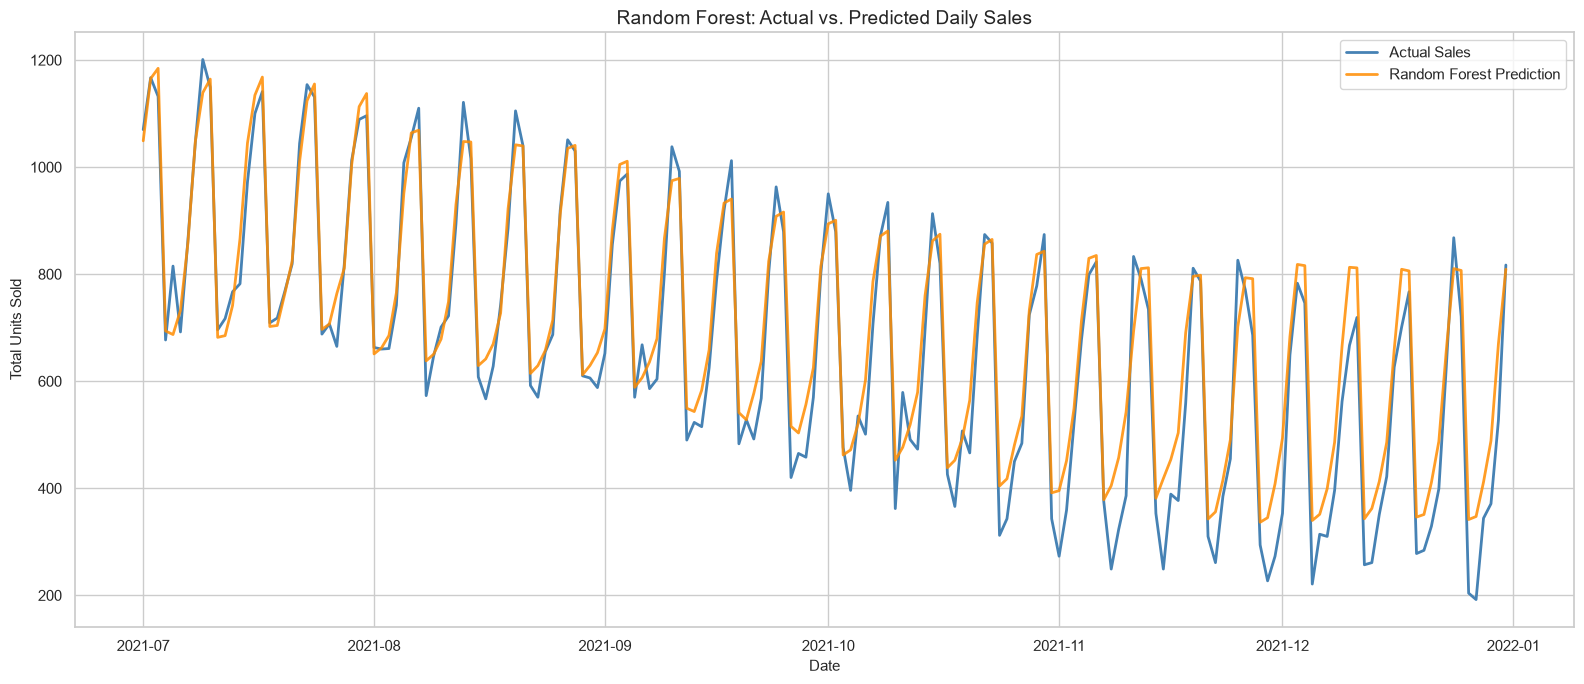

In [41]:
# Create a testing-results dataset
rf_test_results_df = test_df[
    ["date"]
].copy()

rf_test_results_df["actual_units_sold"] = (
    y_test.to_numpy()
)

rf_test_results_df["predicted_units_sold"] = (
    rf_sales_predictions
)

# Aggregate item-level predictions into daily totals
rf_daily_comparison_df = (
    rf_test_results_df.groupby(
        "date",
        as_index=False
    )
    .agg(
        actual_units_sold=(
            "actual_units_sold",
            "sum"
        ),
        predicted_units_sold=(
            "predicted_units_sold",
            "sum"
        )
    )
)

plt.figure(figsize=(16, 7))

plt.plot(
    rf_daily_comparison_df["date"],
    rf_daily_comparison_df["actual_units_sold"],
    label="Actual Sales",
    color="steelblue",
    linewidth=2
)

plt.plot(
    rf_daily_comparison_df["date"],
    rf_daily_comparison_df["predicted_units_sold"],
    label="Random Forest Prediction",
    color="darkorange",
    linewidth=2,
    alpha=0.85
)

plt.title(
    "Random Forest: Actual vs. Predicted Daily Sales"
)
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

### 6.4 XGBoost Regression

XGBoost regression is the final forecasting model evaluated. It builds decision trees sequentially, with each new tree attempting to correct errors made by the preceding trees.

The learning rate, tree depth, row sampling, and feature sampling are constrained to reduce overfitting. The model is trained using the same chronological training period and evaluated using the same final six-month test period as the other models.


In [42]:
from xgboost import XGBRegressor

# Create the XGBoost Regression model
xgb_sales_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=123,
    n_jobs=-1
)

# Train the model using the chronological training period
xgb_training_start = perf_counter()

xgb_sales_model.fit(
    X_train_processed,
    y_train
)

xgb_training_seconds = (
    perf_counter() - xgb_training_start
)

# Generate predictions for the final six months
xgb_prediction_start = perf_counter()

xgb_sales_predictions = xgb_sales_model.predict(
    X_test_processed
)

xgb_prediction_seconds = (
    perf_counter() - xgb_prediction_start
)

print("XGBoost Regression training complete.")

print(
    f"Training time: {xgb_training_seconds:.3f} seconds"
)

print(
    f"Prediction time: {xgb_prediction_seconds:.3f} seconds"
)

XGBoost Regression training complete.
Training time: 1.834 seconds
Prediction time: 0.030 seconds


In [43]:
# Calculate XGBoost performance metrics
xgb_sales_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_sales_predictions
    )
)

xgb_sales_mae = mean_absolute_error(
    y_test,
    xgb_sales_predictions
)

xgb_sales_r2 = r2_score(
    y_test,
    xgb_sales_predictions
)

# Count impossible negative predictions
xgb_negative_prediction_count = int(
    (xgb_sales_predictions < 0).sum()
)

# Store results separately for later comparison
xgb_sales_results_df = pd.DataFrame({
    "Model": ["XGBoost"],
    "RMSE": [xgb_sales_rmse],
    "MAE": [xgb_sales_mae],
    "R2": [xgb_sales_r2],
    "Training Time (Seconds)": [
        xgb_training_seconds
    ],
    "Prediction Time (Seconds)": [
        xgb_prediction_seconds
    ],
    "Negative Predictions": [
        xgb_negative_prediction_count
    ]
})

display(
    xgb_sales_results_df.round({
        "RMSE": 3,
        "MAE": 3,
        "R2": 4,
        "Training Time (Seconds)": 3,
        "Prediction Time (Seconds)": 3
    })
)

,Model,RMSE,MAE,R2,Training Time (Seconds),Prediction Time (Seconds),Negative Predictions
0,XGBoost,6.56,1.54,0.95,1.83,0.03,613


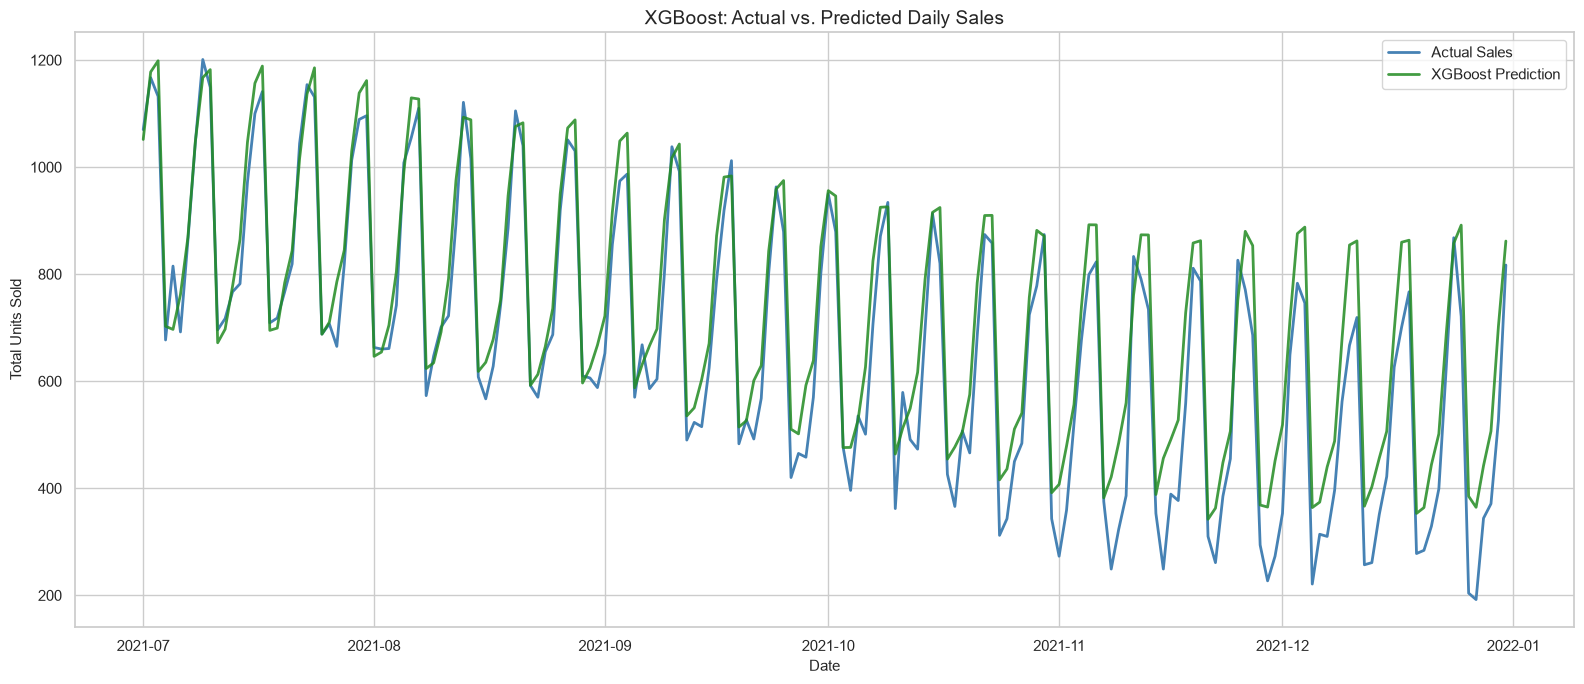

In [44]:
# Create an XGBoost testing-results dataset
xgb_test_results_df = test_df[
    ["date"]
].copy()

xgb_test_results_df["actual_units_sold"] = (
    y_test.to_numpy()
)

xgb_test_results_df["predicted_units_sold"] = (
    xgb_sales_predictions
)

# Aggregate item-level predictions into daily totals
xgb_daily_comparison_df = (
    xgb_test_results_df.groupby(
        "date",
        as_index=False
    )
    .agg(
        actual_units_sold=(
            "actual_units_sold",
            "sum"
        ),
        predicted_units_sold=(
            "predicted_units_sold",
            "sum"
        )
    )
)

plt.figure(figsize=(16, 7))

plt.plot(
    xgb_daily_comparison_df["date"],
    xgb_daily_comparison_df["actual_units_sold"],
    label="Actual Sales",
    color="steelblue",
    linewidth=2
)

plt.plot(
    xgb_daily_comparison_df["date"],
    xgb_daily_comparison_df["predicted_units_sold"],
    label="XGBoost Prediction",
    color="forestgreen",
    linewidth=2,
    alpha=0.85
)

plt.title(
    "XGBoost: Actual vs. Predicted Daily Sales"
)
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

### 6.5 Model Performance Comparison

Linear regression, random forest regression, and XGBoost regression are compared using predictions for the same final six-month testing period.

Root mean squared error (RMSE) is the primary model-selection metric. A smaller RMSE indicates that a model’s predictions are generally closer to the actual item-level sales values. Mean absolute error (MAE), R², computational time, and the number of negative predictions provide additional context.

Although daily aggregated prediction graphs help visualize overall sales patterns, model selection is based primarily on item-level RMSE because aggregation can conceal offsetting overpredictions and underpredictions.


In [45]:
# Combine the results from all three forecasting models
model_comparison_df = pd.concat(
    [
        lr_sales_results_df,
        rf_sales_results_df,
        xgb_sales_results_df
    ],
    ignore_index=True
)

# Calculate improvement relative to Linear Regression
model_comparison_df[
    "RMSE Improvement vs Linear (%)"
] = (
    (
        lr_sales_rmse
        - model_comparison_df["RMSE"]
    )
    / lr_sales_rmse
    * 100
)

# Rank the models from smallest to largest RMSE
model_comparison_df = (
    model_comparison_df
    .sort_values("RMSE")
    .reset_index(drop=True)
)

model_comparison_df.insert(
    0,
    "RMSE Rank",
    range(1, len(model_comparison_df) + 1)
)

display(
    model_comparison_df.round({
        "RMSE": 3,
        "MAE": 3,
        "R2": 4,
        "Training Time (Seconds)": 3,
        "Prediction Time (Seconds)": 3,
        "RMSE Improvement vs Linear (%)": 2
    })
)

,RMSE Rank,Model,RMSE,MAE,R2,Training Time (Seconds),Prediction Time (Seconds),Negative Predictions,RMSE Improvement vs Linear (%)
0,1,Random Forest,4.74,1.18,0.98,23.25,0.05,0,74.30
1,2,XGBoost,6.56,1.54,0.95,1.83,0.03,613,64.41
2,3,Linear Regression,18.43,5.62,0.64,0.07,0.00,5915,0.00


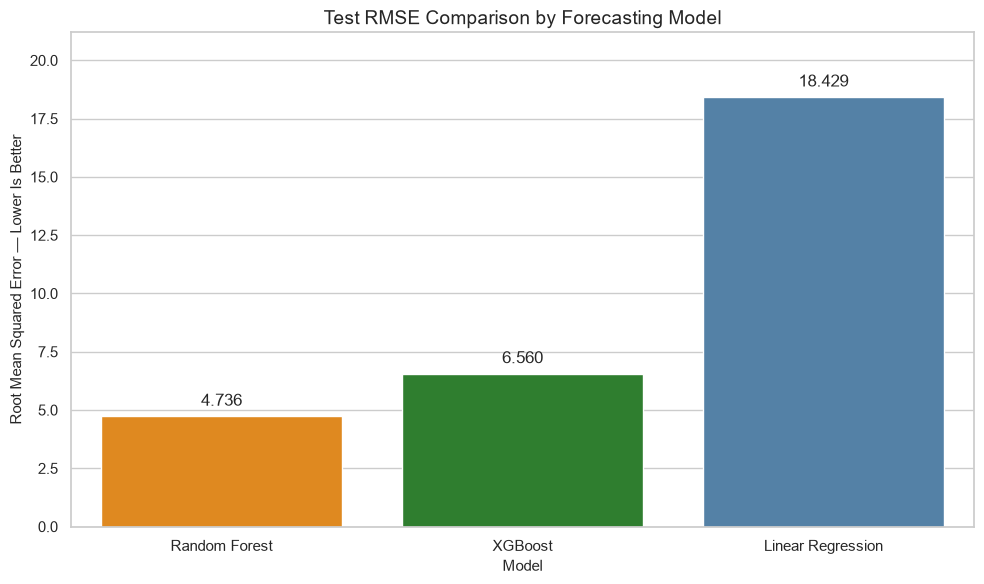

In [46]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=model_comparison_df,
    x="Model",
    y="RMSE",
    hue="Model",
    palette={
        "Linear Regression": "steelblue",
        "Random Forest": "darkorange",
        "XGBoost": "forestgreen"
    },
    legend=False
)

plt.title("Test RMSE Comparison by Forecasting Model")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error — Lower Is Better")

for bar in ax.patches:
    height = bar.get_height()

    ax.annotate(
        f"{height:.3f}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            height
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

plt.ylim(
    0,
    model_comparison_df["RMSE"].max() * 1.15
)

plt.tight_layout()
plt.show()

,month,Random_Forest_RMSE,XGBoost_RMSE
0,2021-07,3.74,4.39
1,2021-08,3.04,4.78
2,2021-09,3.51,5.22
3,2021-10,4.53,6.30
4,2021-11,6.25,8.46
5,2021-12,6.30,8.82


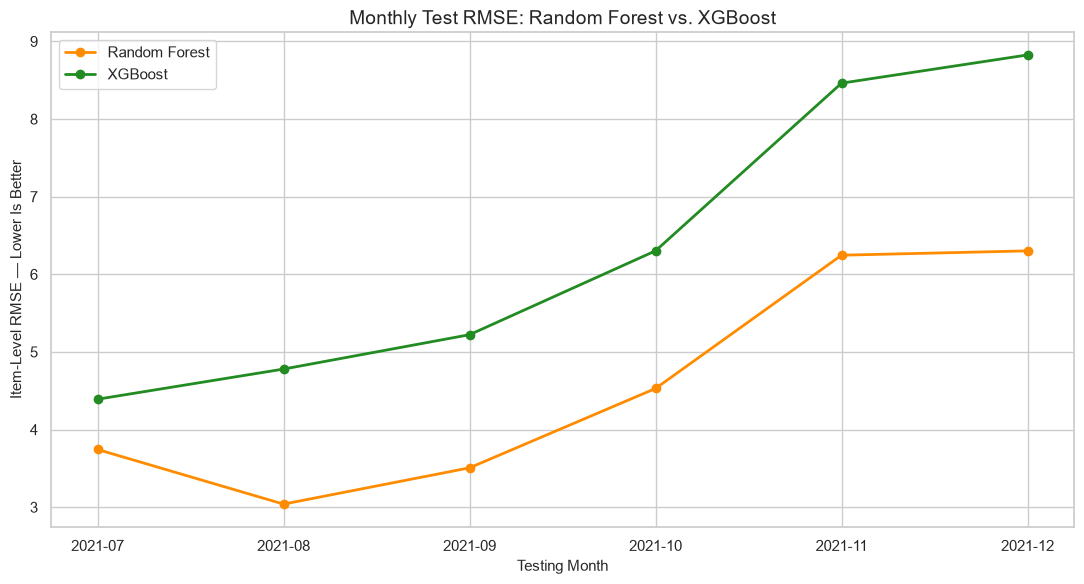

In [47]:
# Compare monthly item-level errors during testing
monthly_error_df = pd.DataFrame({
    "date": test_df["date"].to_numpy(),
    "actual_units_sold": y_test.to_numpy(),
    "Random Forest": rf_sales_predictions,
    "XGBoost": xgb_sales_predictions
})

monthly_error_df["month"] = (
    monthly_error_df["date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_error_df["rf_squared_error"] = (
    monthly_error_df["actual_units_sold"]
    - monthly_error_df["Random Forest"]
) ** 2

monthly_error_df["xgb_squared_error"] = (
    monthly_error_df["actual_units_sold"]
    - monthly_error_df["XGBoost"]
) ** 2

monthly_rmse_df = (
    monthly_error_df.groupby(
        "month",
        as_index=False
    )
    .agg(
        Random_Forest_RMSE=(
            "rf_squared_error",
            lambda values: np.sqrt(values.mean())
        ),
        XGBoost_RMSE=(
            "xgb_squared_error",
            lambda values: np.sqrt(values.mean())
        )
    )
)

display(monthly_rmse_df.round(3))

plt.figure(figsize=(11, 6))

plt.plot(
    monthly_rmse_df["month"],
    monthly_rmse_df["Random_Forest_RMSE"],
    marker="o",
    linewidth=2,
    label="Random Forest",
    color="darkorange"
)

plt.plot(
    monthly_rmse_df["month"],
    monthly_rmse_df["XGBoost_RMSE"],
    marker="o",
    linewidth=2,
    label="XGBoost",
    color="forestgreen"
)

plt.title("Monthly Test RMSE: Random Forest vs. XGBoost")
plt.xlabel("Testing Month")
plt.ylabel("Item-Level RMSE — Lower Is Better")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
# Store the trained models and predictions by name
sales_model_lookup = {
    "Linear Regression": lr_sales_model,
    "Random Forest": rf_sales_model,
    "XGBoost": xgb_sales_model
}

sales_prediction_lookup = {
    "Linear Regression": lr_sales_predictions,
    "Random Forest": rf_sales_predictions,
    "XGBoost": xgb_sales_predictions
}

# Select the model with the smallest test RMSE
best_sales_model_name = (
    model_comparison_df.loc[0, "Model"]
)

best_sales_model = sales_model_lookup[
    best_sales_model_name
]

best_sales_predictions = sales_prediction_lookup[
    best_sales_model_name
]

best_sales_rmse = model_comparison_df.loc[
    0,
    "RMSE"
]

print(
    f"Selected forecasting model: "
    f"{best_sales_model_name}"
)

print(
    f"Lowest test RMSE: "
    f"{best_sales_rmse:.3f}"
)

Selected forecasting model: Random Forest
Lowest test RMSE: 4.736


#### Model Selection

Random forest regression produced the smallest item-level RMSE on the final six-month testing period and was therefore selected as the best-performing forecasting model.

Although the aggregated XGBoost predictions visually followed the daily sales totals closely, aggregation can conceal item-level errors when overpredictions for some items offset underpredictions for others. The common item-level RMSE provides the more reliable comparison because it evaluates every restaurant-item-date prediction separately.

The monthly error analysis also provides context regarding whether performance changed throughout the testing period. However, the final model selection is based on the overall RMSE across the complete July through December 2021 test period.


### 6.6 Final Model Training and 2022 Forecast

After model selection, the winning model is retrained using all available observations from January 2019 through December 2021. This allows the final forecasting model to learn from the newest available sales information before predicting demand for 2022.

The preprocessing transformer is also refitted using the complete historical dataset. A prediction row is then created for every combination of 2022 date and item, producing daily forecasts for each item at its associated restaurant.

The original testing results remain valid because the final six months were not incorporated into training until after model comparison and selection were complete.


In [49]:
from sklearn.base import clone

# Create the complete historical feature matrix
X_full = merged_df[
    model_features
].copy()

# Create the complete historical target
y_full = merged_df[
    "units_sold"
].copy()

# Preserve identifier columns as categorical values
for column in categorical_features:
    X_full[column] = X_full[column].astype(str)

# Create a new, unfitted copy of the preprocessor
final_sales_preprocessor = clone(
    preprocessor
)

# Refit preprocessing using all 2019-2021 observations
X_full_processed = (
    final_sales_preprocessor.fit_transform(
        X_full
    )
)

# Create a new copy of the winning model
final_sales_model = clone(
    best_sales_model
)

# Train the final model using all historical observations
final_training_start = perf_counter()

final_sales_model.fit(
    X_full_processed,
    y_full
)

final_training_seconds = (
    perf_counter() - final_training_start
)

# Verify the completed training dataset
assert len(X_full) == len(y_full)
assert X_full_processed.shape[0] == len(merged_df)
assert X_full.isna().sum().sum() == 0

print(
    "Final forecasting model:",
    best_sales_model_name
)

print(
    "Historical training period:",
    merged_df["date"].min(),
    "to",
    merged_df["date"].max()
)

print(
    f"Historical training rows: "
    f"{len(X_full):,}"
)

print(
    f"Final training time: "
    f"{final_training_seconds:.3f} seconds"
)

print(
    "Processed feature count:",
    X_full_processed.shape[1]
)

Final forecasting model: Random Forest
Historical training period: 2019-01-01 00:00:00 to 2021-12-31 00:00:00
Historical training rows: 109,600
Final training time: 30.195 seconds
Processed feature count: 120


In [50]:
# Create every date in the 2022 forecasting period
future_dates = pd.date_range(
    start="2022-01-01",
    end="2022-12-31",
    freq="D"
)

# Keep the restaurant associated with each item
item_restaurant_lookup_df = (
    merged_df[
        [
            "item_id",
            "restaurant_id"
        ]
    ]
    .drop_duplicates()
    .sort_values("item_id")
    .reset_index(drop=True)
)

# Confirm that each item belongs to only one restaurant
assert (
    item_restaurant_lookup_df
    .groupby("item_id")["restaurant_id"]
    .nunique()
    .eq(1)
    .all()
)

# Create one row for every 2022 date and item
future_sales_df = (
    pd.DataFrame({
        "date": future_dates
    })
    .merge(
        item_restaurant_lookup_df,
        how="cross"
    )
)

# Generate the same calendar features used during training
future_sales_df["year"] = (
    future_sales_df["date"].dt.year
)

future_sales_df["quarter"] = (
    future_sales_df["date"].dt.quarter
)

future_sales_df["month"] = (
    future_sales_df["date"].dt.month
)

future_sales_df["day_of_month"] = (
    future_sales_df["date"].dt.day
)

future_sales_df["day_of_week"] = (
    future_sales_df["date"].dt.dayofweek
)

future_sales_df["week_of_year"] = (
    future_sales_df["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

future_sales_df["is_weekend"] = (
    future_sales_df["day_of_week"]
    .isin([5, 6])
    .astype(int)
)

future_sales_df["day_of_year"] = (
    future_sales_df["date"].dt.dayofyear
)

# Generate cyclical calendar features
future_sales_df["month_sin"] = np.sin(
    2 * np.pi
    * future_sales_df["month"]
    / 12
)

future_sales_df["month_cos"] = np.cos(
    2 * np.pi
    * future_sales_df["month"]
    / 12
)

future_sales_df["day_of_week_sin"] = np.sin(
    2 * np.pi
    * future_sales_df["day_of_week"]
    / 7
)

future_sales_df["day_of_week_cos"] = np.cos(
    2 * np.pi
    * future_sales_df["day_of_week"]
    / 7
)

future_sales_df["day_of_year_sin"] = np.sin(
    2 * np.pi
    * future_sales_df["day_of_year"]
    / 365.25
)

future_sales_df["day_of_year_cos"] = np.cos(
    2 * np.pi
    * future_sales_df["day_of_year"]
    / 365.25
)

# Verify the complete forecasting grid
expected_future_rows = (
    len(future_dates)
    * item_restaurant_lookup_df["item_id"].nunique()
)

assert len(future_sales_df) == expected_future_rows
assert future_sales_df["date"].min() == pd.Timestamp(
    "2022-01-01"
)
assert future_sales_df["date"].max() == pd.Timestamp(
    "2022-12-31"
)
assert (
    future_sales_df[model_features]
    .isna()
    .sum()
    .sum()
    == 0
)

print(
    "Forecasting period:",
    future_sales_df["date"].min(),
    "to",
    future_sales_df["date"].max()
)

print(
    "Items forecast per day:",
    future_sales_df["item_id"].nunique()
)

print(
    f"Total forecasting rows: "
    f"{len(future_sales_df):,}"
)

Forecasting period: 2022-01-01 00:00:00 to 2022-12-31 00:00:00
Items forecast per day: 100
Total forecasting rows: 36,500


In [51]:
# Select the model features for the future period
X_2022 = future_sales_df[
    model_features
].copy()

# Preserve identifier columns as categorical values
for column in categorical_features:
    X_2022[column] = X_2022[column].astype(str)

# Apply preprocessing learned from all historical data
X_2022_processed = (
    final_sales_preprocessor.transform(
        X_2022
    )
)

# Generate the raw 2022 sales predictions
forecast_2022_raw_predictions = (
    final_sales_model.predict(
        X_2022_processed
    )
)

# Count any impossible negative forecasts
forecast_2022_negative_count = int(
    (forecast_2022_raw_predictions < 0).sum()
)

# Prevent negative demand in the business forecast
forecast_2022_predictions = np.clip(
    forecast_2022_raw_predictions,
    a_min=0,
    a_max=None
)

# Retrieve readable item and restaurant details
future_item_details_df = (
    merged_df[
        [
            "item_id",
            "restaurant_id",
            "item_name",
            "restaurant_name",
            "item_cost",
            "calories"
        ]
    ]
    .drop_duplicates()
)

# Assemble the final item-level forecast
forecast_2022_df = (
    future_sales_df[
        [
            "date",
            "item_id",
            "restaurant_id"
        ]
    ]
    .merge(
        future_item_details_df,
        on=[
            "item_id",
            "restaurant_id"
        ],
        how="left",
        validate="many_to_one"
    )
)

forecast_2022_df["predicted_units_sold"] = (
    forecast_2022_predictions
)

forecast_2022_df["predicted_revenue"] = (
    forecast_2022_df["predicted_units_sold"]
    * forecast_2022_df["item_cost"]
)

# Verify the completed forecast
assert len(forecast_2022_df) == 36500
assert forecast_2022_df.isna().sum().sum() == 0
assert (
    forecast_2022_df["predicted_units_sold"] >= 0
).all()

print(
    f"Completed forecast rows: "
    f"{len(forecast_2022_df):,}"
)

print(
    f"Raw negative predictions corrected: "
    f"{forecast_2022_negative_count:,}"
)

print("\nForecasted unit-sales summary:")

display(
    forecast_2022_df[
        "predicted_units_sold"
    ]
    .describe()
    .round(2)
)

print("\nFirst ten forecast rows:")

display(
    forecast_2022_df.head(10).round({
        "item_cost": 2,
        "predicted_units_sold": 2,
        "predicted_revenue": 2
    })
)

Completed forecast rows: 36,500
Raw negative predictions corrected: 0

Forecasted unit-sales summary:


count   36,500.00
mean         6.75
std         31.02
min          0.00
25%          0.02
50%          0.02
75%          0.60
max        438.10
Name: predicted_units_sold, dtype: float64


First ten forecast rows:


,date,item_id,restaurant_id,item_name,restaurant_name,item_cost,calories,predicted_units_sold,predicted_revenue
0,2022-01-01,1,4,Chocolate Cake,Fou Cher,6.71,554,0.02,0.11
1,2022-01-01,2,4,Breaded Fish with Vegetables Meal,Fou Cher,15.09,772,0.02,0.24
2,2022-01-01,3,1,Sweet Fruity Cake,Bob's Diner,29.22,931,2.24,65.51
3,2022-01-01,4,1,Amazing Steak Dinner with Rolls,Bob's Diner,26.42,763,32.39,855.62
4,2022-01-01,5,5,Milk Cake,Corner Cafe,6.07,583,0.02,0.10
5,2022-01-01,6,4,Fruity Frozen Cocktail,Fou Cher,5.61,537,0.02,0.09
6,2022-01-01,7,4,Fruity Milky Cake,Fou Cher,8.10,605,0.02,0.13
7,2022-01-01,8,6,Amazing Trout with Vegetables Dinner,Surfs Up,24.98,258,0.09,2.26
8,2022-01-01,9,1,Orange Juice,Bob's Diner,3.91,135,85.90,335.88
9,2022-01-01,10,5,Mutton with Roles and Vegetables Plate,Corner Cafe,21.13,820,0.02,0.35


### 6.7 Analysis of the 2022 Forecast

The completed 2022 forecast is analyzed at the monthly, restaurant, and item levels. Aggregating the item-date predictions helps identify seasonal demand patterns, the restaurants expected to generate the greatest sales volume, and the products forecast to be most popular.

Forecasted units represent expected demand, while predicted revenue estimates the corresponding sales value based on each item’s listed cost.


In [52]:
# Create a monthly date field
forecast_2022_df["forecast_month"] = (
    forecast_2022_df["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Aggregate all item forecasts into monthly totals
monthly_forecast_2022_df = (
    forecast_2022_df.groupby(
        "forecast_month",
        as_index=False
    )
    .agg(
        predicted_units_sold=(
            "predicted_units_sold",
            "sum"
        ),
        predicted_revenue=(
            "predicted_revenue",
            "sum"
        )
    )
)

# Calculate average total units sold per day
monthly_forecast_2022_df["days_in_month"] = (
    monthly_forecast_2022_df[
        "forecast_month"
    ].dt.days_in_month
)

monthly_forecast_2022_df[
    "average_daily_units_sold"
] = (
    monthly_forecast_2022_df[
        "predicted_units_sold"
    ]
    / monthly_forecast_2022_df["days_in_month"]
)

# Calculate each month's share of annual demand
monthly_forecast_2022_df[
    "annual_demand_share_pct"
] = (
    monthly_forecast_2022_df[
        "predicted_units_sold"
    ]
    / monthly_forecast_2022_df[
        "predicted_units_sold"
    ].sum()
    * 100
)

# Create readable month labels
monthly_forecast_2022_df["month"] = (
    monthly_forecast_2022_df[
        "forecast_month"
    ].dt.strftime("%B %Y")
)

# Verify that aggregation preserved the totals
assert np.isclose(
    monthly_forecast_2022_df[
        "predicted_units_sold"
    ].sum(),
    forecast_2022_df[
        "predicted_units_sold"
    ].sum()
)

assert np.isclose(
    monthly_forecast_2022_df[
        "predicted_revenue"
    ].sum(),
    forecast_2022_df[
        "predicted_revenue"
    ].sum()
)

display(
    monthly_forecast_2022_df[
        [
            "month",
            "predicted_units_sold",
            "average_daily_units_sold",
            "predicted_revenue",
            "annual_demand_share_pct"
        ]
    ].round({
        "predicted_units_sold": 0,
        "average_daily_units_sold": 2,
        "predicted_revenue": 2,
        "annual_demand_share_pct": 2
    })
)

,month,predicted_units_sold,average_daily_units_sold,predicted_revenue,annual_demand_share_pct
0,January 2022,"14,591.00",470.69,"142,106.41",5.93
1,February 2022,"15,139.00",540.69,"145,981.19",6.15
2,March 2022,"19,502.00",629.08,"188,520.29",7.92
3,April 2022,"22,682.00",756.05,"219,682.58",9.21
4,May 2022,"25,143.00",811.06,"242,180.48",10.21
5,June 2022,"26,912.00",897.05,"259,294.89",10.93
6,July 2022,"27,928.00",900.92,"268,327.48",11.34
7,August 2022,"24,428.00",787.99,"233,903.94",9.92
8,September 2022,"21,400.00",713.34,"205,687.59",8.69
9,October 2022,"18,263.00",589.14,"175,388.45",7.42


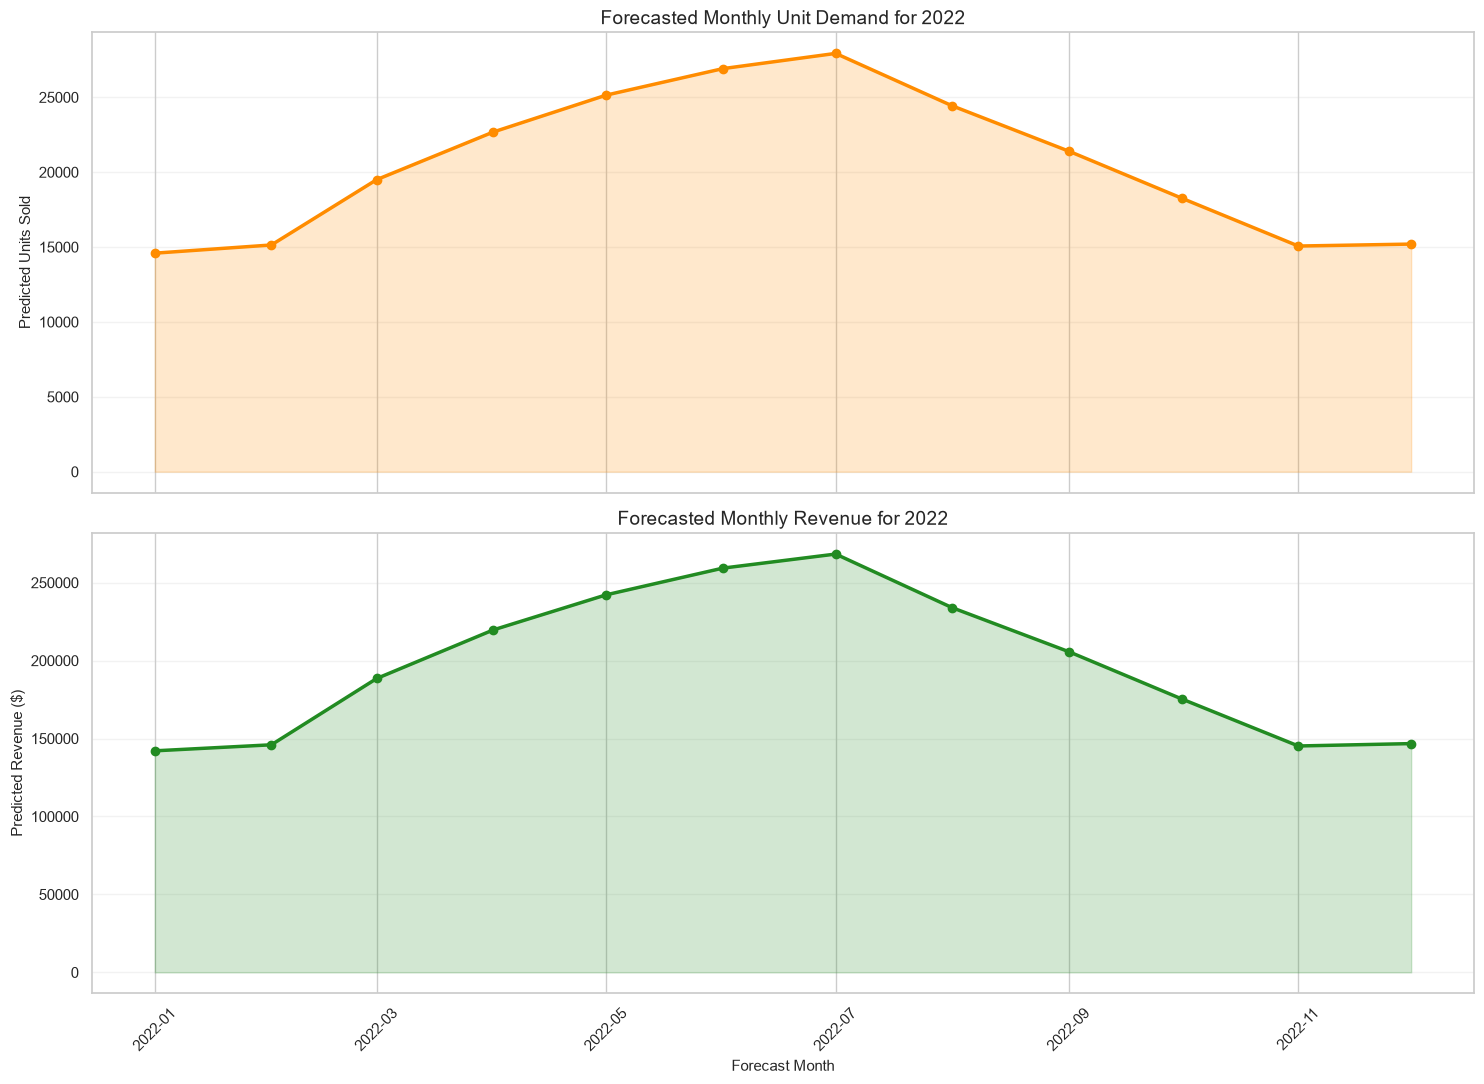

In [53]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(15, 11),
    sharex=True
)

# Plot forecasted monthly unit demand
axes[0].plot(
    monthly_forecast_2022_df["forecast_month"],
    monthly_forecast_2022_df[
        "predicted_units_sold"
    ],
    marker="o",
    linewidth=2.5,
    color="darkorange"
)

axes[0].fill_between(
    monthly_forecast_2022_df["forecast_month"],
    monthly_forecast_2022_df[
        "predicted_units_sold"
    ],
    alpha=0.2,
    color="darkorange"
)

axes[0].set_title(
    "Forecasted Monthly Unit Demand for 2022"
)
axes[0].set_ylabel("Predicted Units Sold")
axes[0].grid(axis="y", alpha=0.25)

# Plot forecasted monthly revenue
axes[1].plot(
    monthly_forecast_2022_df["forecast_month"],
    monthly_forecast_2022_df[
        "predicted_revenue"
    ],
    marker="o",
    linewidth=2.5,
    color="forestgreen"
)

axes[1].fill_between(
    monthly_forecast_2022_df["forecast_month"],
    monthly_forecast_2022_df[
        "predicted_revenue"
    ],
    alpha=0.2,
    color="forestgreen"
)

axes[1].set_title(
    "Forecasted Monthly Revenue for 2022"
)
axes[1].set_xlabel("Forecast Month")
axes[1].set_ylabel("Predicted Revenue ($)")
axes[1].grid(axis="y", alpha=0.25)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,demand_rank,restaurant_id,restaurant_name,predicted_units_sold,predicted_revenue,average_daily_units_sold,annual_demand_share_pct
0,1,1,Bob's Diner,"243,806.00","2,350,920.74",667.96,99.01
1,2,3,Sweet Shack,617.00,"1,033.92",1.69,0.25
2,3,6,Surfs Up,592.00,"5,259.15",1.62,0.24
3,4,2,Beachfront Bar,437.00,"1,283.66",1.20,0.18
4,5,5,Corner Cafe,431.00,"4,877.52",1.18,0.18
5,6,4,Fou Cher,371.00,"9,670.69",1.02,0.15


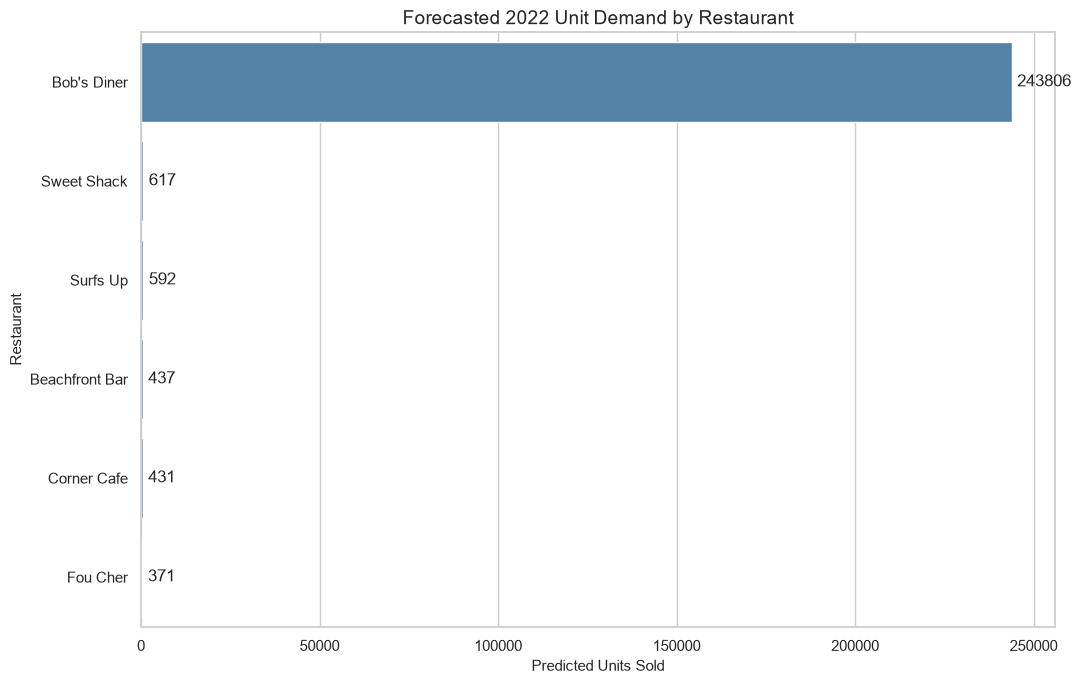

In [54]:
# Aggregate the forecast by restaurant
restaurant_forecast_2022_df = (
    forecast_2022_df.groupby(
        [
            "restaurant_id",
            "restaurant_name"
        ],
        as_index=False
    )
    .agg(
        predicted_units_sold=(
            "predicted_units_sold",
            "sum"
        ),
        predicted_revenue=(
            "predicted_revenue",
            "sum"
        )
    )
)

# Calculate restaurant-level daily demand
restaurant_forecast_2022_df[
    "average_daily_units_sold"
] = (
    restaurant_forecast_2022_df[
        "predicted_units_sold"
    ]
    / len(future_dates)
)

# Calculate share of total forecasted demand
restaurant_forecast_2022_df[
    "annual_demand_share_pct"
] = (
    restaurant_forecast_2022_df[
        "predicted_units_sold"
    ]
    / restaurant_forecast_2022_df[
        "predicted_units_sold"
    ].sum()
    * 100
)

# Rank restaurants by forecasted unit demand
restaurant_forecast_2022_df = (
    restaurant_forecast_2022_df
    .sort_values(
        "predicted_units_sold",
        ascending=False
    )
    .reset_index(drop=True)
)

restaurant_forecast_2022_df.insert(
    0,
    "demand_rank",
    range(
        1,
        len(restaurant_forecast_2022_df) + 1
    )
)

display(
    restaurant_forecast_2022_df.round({
        "predicted_units_sold": 0,
        "average_daily_units_sold": 2,
        "predicted_revenue": 2,
        "annual_demand_share_pct": 2
    })
)

# Visualize forecasted demand by restaurant
plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=restaurant_forecast_2022_df,
    x="predicted_units_sold",
    y="restaurant_name",
    color="steelblue"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4
    )

plt.title(
    "Forecasted 2022 Unit Demand by Restaurant"
)
plt.xlabel("Predicted Units Sold")
plt.ylabel("Restaurant")
plt.tight_layout()
plt.show()

,demand_rank,item_id,item_name,restaurant_id,restaurant_name,predicted_units_sold,predicted_revenue,average_daily_units_sold
0,1,19,Strawberry Smoothy,1,Bob's Diner,"91,284.00","263,810.56",250.09
1,2,38,Mutton Dinner,1,Bob's Diner,"38,654.00","417,462.38",105.90
2,3,9,Orange Juice,1,Bob's Diner,"29,053.00","113,598.69",79.60
3,4,76,Amazing pork lunch,1,Bob's Diner,"21,848.00","391,732.23",59.86
4,5,59,Blue Ribbon Beef Entree,1,Bob's Diner,"16,155.00","377,549.07",44.26
5,6,13,Sweet Frozen Soft Drink,1,Bob's Diner,"12,819.00","53,582.07",35.12
6,7,4,Amazing Steak Dinner with Rolls,1,Bob's Diner,"11,272.00","297,801.05",30.88
7,8,56,Sea Bass with Vegetables Dinner,1,Bob's Diner,"8,111.00","233,191.97",22.22
8,9,21,Amazing Fish with Vegetables Meal,1,Bob's Diner,"4,174.00","96,971.19",11.44
9,10,73,Milky Cake,1,Bob's Diner,"2,136.00","11,021.10",5.85


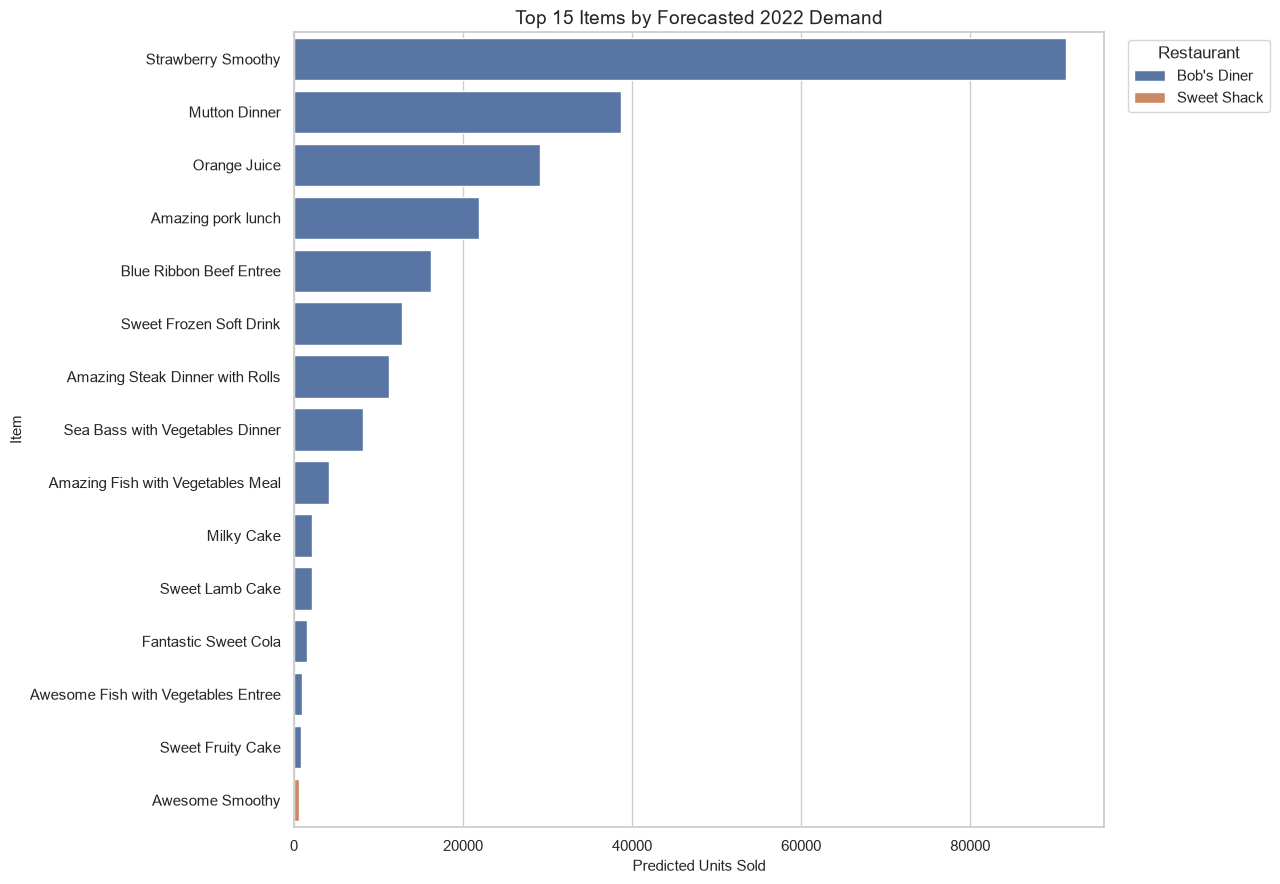

In [55]:
# Aggregate the forecast by item and restaurant
item_forecast_2022_df = (
    forecast_2022_df.groupby(
        [
            "item_id",
            "item_name",
            "restaurant_id",
            "restaurant_name"
        ],
        as_index=False
    )
    .agg(
        predicted_units_sold=(
            "predicted_units_sold",
            "sum"
        ),
        predicted_revenue=(
            "predicted_revenue",
            "sum"
        )
    )
)

# Calculate average daily item demand
item_forecast_2022_df[
    "average_daily_units_sold"
] = (
    item_forecast_2022_df[
        "predicted_units_sold"
    ]
    / len(future_dates)
)

# Rank all items by forecasted demand
item_forecast_2022_df = (
    item_forecast_2022_df
    .sort_values(
        "predicted_units_sold",
        ascending=False
    )
    .reset_index(drop=True)
)

item_forecast_2022_df.insert(
    0,
    "demand_rank",
    range(
        1,
        len(item_forecast_2022_df) + 1
    )
)

top_15_forecast_items_df = (
    item_forecast_2022_df
    .head(15)
    .copy()
)

display(
    top_15_forecast_items_df.round({
        "predicted_units_sold": 0,
        "average_daily_units_sold": 2,
        "predicted_revenue": 2
    })
)

# Visualize the 15 items with the greatest demand
plt.figure(figsize=(13, 9))

ax = sns.barplot(
    data=top_15_forecast_items_df,
    x="predicted_units_sold",
    y="item_name",
    hue="restaurant_name",
    dodge=False
)

plt.title(
    "Top 15 Items by Forecasted 2022 Demand"
)
plt.xlabel("Predicted Units Sold")
plt.ylabel("Item")
plt.legend(
    title="Restaurant",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [56]:
# Locate the highest-demand item within each restaurant
top_item_indexes = (
    item_forecast_2022_df.groupby(
        "restaurant_id"
    )["predicted_units_sold"]
    .idxmax()
)

top_item_per_restaurant_2022_df = (
    item_forecast_2022_df.loc[
        top_item_indexes
    ]
    .sort_values(
        "predicted_units_sold",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    top_item_per_restaurant_2022_df[
        [
            "restaurant_name",
            "item_id",
            "item_name",
            "predicted_units_sold",
            "average_daily_units_sold",
            "predicted_revenue"
        ]
    ].round({
        "predicted_units_sold": 0,
        "average_daily_units_sold": 2,
        "predicted_revenue": 2
    })
)

# Identify overall forecast leaders
highest_demand_month = (
    monthly_forecast_2022_df.loc[
        monthly_forecast_2022_df[
            "predicted_units_sold"
        ].idxmax()
    ]
)

highest_revenue_month = (
    monthly_forecast_2022_df.loc[
        monthly_forecast_2022_df[
            "predicted_revenue"
        ].idxmax()
    ]
)

highest_demand_restaurant = (
    restaurant_forecast_2022_df.iloc[0]
)

highest_demand_item = (
    item_forecast_2022_df.iloc[0]
)

print(
    "Highest-demand month:",
    highest_demand_month["month"]
)

print(
    "Highest-revenue month:",
    highest_revenue_month["month"]
)

print(
    "Highest-demand restaurant:",
    highest_demand_restaurant[
        "restaurant_name"
    ]
)

print(
    "Highest-demand item:",
    highest_demand_item["item_name"],
    "at",
    highest_demand_item["restaurant_name"]
)

,restaurant_name,item_id,item_name,predicted_units_sold,average_daily_units_sold,predicted_revenue
0,Bob's Diner,19,Strawberry Smoothy,"91,284.00",250.09,"263,810.56"
1,Sweet Shack,49,Awesome Smoothy,578.00,1.58,802.80
2,Beachfront Bar,42,Fantastic Milky Smoothy,381.00,1.04,"1,108.23"
3,Surfs Up,89,Awesome Soft Drink,319.00,0.87,975.51
4,Fou Cher,80,Blue Ribbon Fruity Vegi Lunch,112.00,0.31,"6,030.39"
5,Corner Cafe,71,Frozen Milky Smoothy,104.00,0.29,414.37


Highest-demand month: July 2022
Highest-revenue month: July 2022
Highest-demand restaurant: Bob's Diner
Highest-demand item: Strawberry Smoothy at Bob's Diner


### 6.8 Restaurant-Adjusted Item Performance

Raw unit forecasts are important for inventory planning, but they are not sufficient for comparing product strength across restaurants operating at substantially different sales volumes.

To create a fairer comparison, each item is evaluated relative to the average forecasted demand of items at the same restaurant. A relative-demand index of 100 represents the restaurant’s average item. Values above 100 indicate above-average demand, while values below 100 indicate below-average demand.

This analysis distinguishes absolute sales volume from relative menu performance. An item can be a particularly strong performer within its restaurant even if its total unit sales are lower than those of items sold by a much larger restaurant.


In [57]:
# Preserve the original item forecast table
adjusted_item_forecast_2022_df = (
    item_forecast_2022_df.copy()
)

# Calculate each restaurant's total forecasted demand
adjusted_item_forecast_2022_df[
    "restaurant_total_units"
] = (
    adjusted_item_forecast_2022_df
    .groupby("restaurant_id")[
        "predicted_units_sold"
    ]
    .transform("sum")
)

# Calculate average annual demand per menu item
adjusted_item_forecast_2022_df[
    "restaurant_average_item_units"
] = (
    adjusted_item_forecast_2022_df
    .groupby("restaurant_id")[
        "predicted_units_sold"
    ]
    .transform("mean")
)

# Count the number of items offered by each restaurant
adjusted_item_forecast_2022_df[
    "restaurant_menu_item_count"
] = (
    adjusted_item_forecast_2022_df
    .groupby("restaurant_id")[
        "item_id"
    ]
    .transform("count")
)

# Calculate each item's percentage of its restaurant's demand
adjusted_item_forecast_2022_df[
    "restaurant_demand_share_pct"
] = (
    adjusted_item_forecast_2022_df[
        "predicted_units_sold"
    ]
    / adjusted_item_forecast_2022_df[
        "restaurant_total_units"
    ]
    * 100
)

# Index each item relative to its restaurant's average item
adjusted_item_forecast_2022_df[
    "relative_demand_index"
] = (
    adjusted_item_forecast_2022_df[
        "predicted_units_sold"
    ]
    / adjusted_item_forecast_2022_df[
        "restaurant_average_item_units"
    ]
    * 100
)

# Rank each item only against items at the same restaurant
adjusted_item_forecast_2022_df[
    "within_restaurant_rank"
] = (
    adjusted_item_forecast_2022_df
    .groupby("restaurant_id")[
        "predicted_units_sold"
    ]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)

# Verify that each restaurant's average index equals 100
restaurant_index_check = (
    adjusted_item_forecast_2022_df
    .groupby("restaurant_name")[
        "relative_demand_index"
    ]
    .mean()
)

assert np.allclose(
    restaurant_index_check.to_numpy(),
    100
)

print(
    "Restaurant-adjusted item metrics "
    "calculated successfully."
)

display(
    restaurant_index_check
    .rename("Average Relative-Demand Index")
    .round(2)
)

Restaurant-adjusted item metrics calculated successfully.


restaurant_name
Beachfront Bar   100.00
Bob's Diner      100.00
Corner Cafe      100.00
Fou Cher         100.00
Surfs Up         100.00
Sweet Shack      100.00
Name: Average Relative-Demand Index, dtype: float64

In [58]:
# Select the highest-demand item within each restaurant
top_adjusted_item_per_restaurant_2022_df = (
    adjusted_item_forecast_2022_df[
        adjusted_item_forecast_2022_df[
            "within_restaurant_rank"
        ] == 1
    ]
    .sort_values(
        "relative_demand_index",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    top_adjusted_item_per_restaurant_2022_df[
        [
            "restaurant_name",
            "item_name",
            "restaurant_menu_item_count",
            "predicted_units_sold",
            "average_daily_units_sold",
            "restaurant_demand_share_pct",
            "relative_demand_index"
        ]
    ].round({
        "predicted_units_sold": 0,
        "average_daily_units_sold": 2,
        "restaurant_demand_share_pct": 2,
        "relative_demand_index": 1
    })
)

,restaurant_name,item_name,restaurant_menu_item_count,predicted_units_sold,average_daily_units_sold,restaurant_demand_share_pct,relative_demand_index
0,Bob's Diner,Strawberry Smoothy,24,"91,284.00",250.09,37.44,898.60
1,Fou Cher,Blue Ribbon Fruity Vegi Lunch,28,112.00,0.31,30.10,842.90
2,Sweet Shack,Awesome Smoothy,8,578.00,1.58,93.56,748.50
3,Corner Cafe,Frozen Milky Smoothy,24,104.00,0.29,24.15,579.50
4,Surfs Up,Awesome Soft Drink,10,319.00,0.87,53.85,538.50
5,Beachfront Bar,Fantastic Milky Smoothy,6,381.00,1.04,87.07,522.40


In [59]:
# Rank every item using restaurant-adjusted demand
relative_item_ranking_2022_df = (
    adjusted_item_forecast_2022_df
    .sort_values(
        [
            "relative_demand_index",
            "predicted_units_sold"
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

relative_item_ranking_2022_df.insert(
    0,
    "relative_strength_rank",
    range(
        1,
        len(relative_item_ranking_2022_df) + 1
    )
)

top_15_relative_items_2022_df = (
    relative_item_ranking_2022_df
    .head(15)
    .copy()
)

display(
    top_15_relative_items_2022_df[
        [
            "relative_strength_rank",
            "restaurant_name",
            "item_name",
            "within_restaurant_rank",
            "predicted_units_sold",
            "restaurant_demand_share_pct",
            "relative_demand_index"
        ]
    ].round({
        "predicted_units_sold": 0,
        "restaurant_demand_share_pct": 2,
        "relative_demand_index": 1
    })
)

,relative_strength_rank,restaurant_name,item_name,within_restaurant_rank,predicted_units_sold,restaurant_demand_share_pct,relative_demand_index
0,1,Bob's Diner,Strawberry Smoothy,1,"91,284.00",37.44,898.60
1,2,Fou Cher,Blue Ribbon Fruity Vegi Lunch,1,112.00,30.10,842.90
2,3,Sweet Shack,Awesome Smoothy,1,578.00,93.56,748.50
3,4,Corner Cafe,Frozen Milky Smoothy,1,104.00,24.15,579.50
4,5,Surfs Up,Awesome Soft Drink,1,319.00,53.85,538.50
5,6,Beachfront Bar,Fantastic Milky Smoothy,1,381.00,87.07,522.40
6,7,Bob's Diner,Mutton Dinner,2,"38,654.00",15.85,380.50
7,8,Corner Cafe,Lamb with Bread Entree,2,65.00,15.06,361.50
8,9,Fou Cher,Original Fruity Cod with Bread and Vegetables ...,2,45.00,12.17,340.60
9,10,Corner Cafe,Blue Ribbon Lamb with Rolls Lunch,3,52.00,12.09,290.20


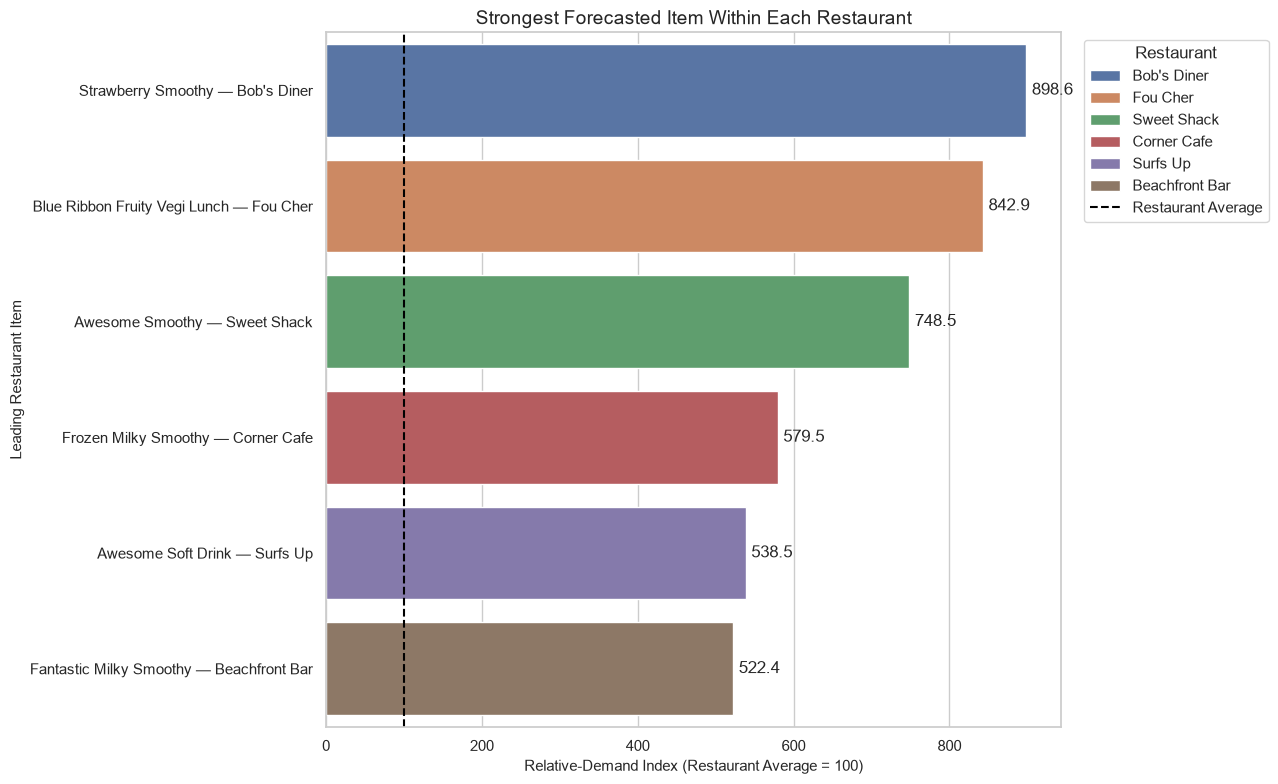

Highest absolute-volume item: Strawberry Smoothy at Bob's Diner
Strongest restaurant-adjusted item: Strawberry Smoothy at Bob's Diner
Relative-demand index: 898.6


In [60]:
# Create a readable restaurant-item label
top_adjusted_item_per_restaurant_2022_df[
    "item_label"
] = (
    top_adjusted_item_per_restaurant_2022_df[
        "item_name"
    ]
    + " — "
    + top_adjusted_item_per_restaurant_2022_df[
        "restaurant_name"
    ]
)

plt.figure(figsize=(13, 8))

ax = sns.barplot(
    data=top_adjusted_item_per_restaurant_2022_df,
    x="relative_demand_index",
    y="item_label",
    hue="restaurant_name",
    dodge=False
)

# Mark the restaurant-average benchmark
plt.axvline(
    x=100,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Restaurant Average"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=4
    )

plt.title(
    "Strongest Forecasted Item Within Each Restaurant"
)
plt.xlabel(
    "Relative-Demand Index "
    "(Restaurant Average = 100)"
)
plt.ylabel("Leading Restaurant Item")
plt.legend(
    title="Restaurant",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

# Print the two distinct company-wide leaders
absolute_demand_leader = (
    adjusted_item_forecast_2022_df
    .sort_values(
        "predicted_units_sold",
        ascending=False
    )
    .iloc[0]
)

relative_menu_leader = (
    relative_item_ranking_2022_df.iloc[0]
)

print(
    "Highest absolute-volume item:",
    absolute_demand_leader["item_name"],
    "at",
    absolute_demand_leader["restaurant_name"]
)

print(
    "Strongest restaurant-adjusted item:",
    relative_menu_leader["item_name"],
    "at",
    relative_menu_leader["restaurant_name"]
)

print(
    "Relative-demand index:",
    f"{relative_menu_leader['relative_demand_index']:.1f}"
)

### 6.9 Forecast Export and Final Validation

The completed forecast and supporting summaries are exported as CSV files for future analysis and business use. The exported deliverables include the complete item-level forecast, monthly totals, restaurant-level performance, restaurant-adjusted item rankings, and model-comparison results.

Final validation checks confirm that the forecast covers every date and item in 2022, contains no duplicate or missing observations, includes no negative demand estimates, and reconciles across the item, restaurant, and monthly summaries.


In [61]:
from pathlib import Path

# Create a folder for the final forecast deliverables
forecast_output_dir = (
    Path.cwd()
    / "sales_forecast_outputs"
)

forecast_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Prepare the complete item-date forecast
forecast_export_df = forecast_2022_df[
    [
        "date",
        "item_id",
        "item_name",
        "restaurant_id",
        "restaurant_name",
        "item_cost",
        "calories",
        "predicted_units_sold",
        "predicted_revenue"
    ]
].copy()

forecast_export_df = forecast_export_df.round({
    "item_cost": 2,
    "predicted_units_sold": 3,
    "predicted_revenue": 2
})

# Prepare the monthly forecast summary
monthly_export_df = monthly_forecast_2022_df[
    [
        "forecast_month",
        "month",
        "predicted_units_sold",
        "average_daily_units_sold",
        "predicted_revenue",
        "annual_demand_share_pct"
    ]
].copy()

monthly_export_df = monthly_export_df.round({
    "predicted_units_sold": 3,
    "average_daily_units_sold": 3,
    "predicted_revenue": 2,
    "annual_demand_share_pct": 3
})

# Prepare the restaurant forecast summary
restaurant_export_df = (
    restaurant_forecast_2022_df.copy()
)

restaurant_export_df = restaurant_export_df.round({
    "predicted_units_sold": 3,
    "average_daily_units_sold": 3,
    "predicted_revenue": 2,
    "annual_demand_share_pct": 3
})

# Prepare the restaurant-adjusted item ranking
adjusted_item_export_df = (
    relative_item_ranking_2022_df[
        [
            "relative_strength_rank",
            "restaurant_name",
            "restaurant_id",
            "item_name",
            "item_id",
            "within_restaurant_rank",
            "restaurant_menu_item_count",
            "predicted_units_sold",
            "average_daily_units_sold",
            "predicted_revenue",
            "restaurant_demand_share_pct",
            "relative_demand_index"
        ]
    ]
    .copy()
)

adjusted_item_export_df = (
    adjusted_item_export_df.round({
        "predicted_units_sold": 3,
        "average_daily_units_sold": 3,
        "predicted_revenue": 2,
        "restaurant_demand_share_pct": 3,
        "relative_demand_index": 3
    })
)

# Prepare the model-comparison results
model_comparison_export_df = (
    model_comparison_df.copy()
)

# Define the output file paths
export_file_lookup = {
    "Complete 2022 Forecast": (
        forecast_output_dir
        / "complete_2022_sales_forecast.csv"
    ),
    "Monthly Forecast Summary": (
        forecast_output_dir
        / "monthly_2022_forecast_summary.csv"
    ),
    "Restaurant Forecast Summary": (
        forecast_output_dir
        / "restaurant_2022_forecast_summary.csv"
    ),
    "Adjusted Item Rankings": (
        forecast_output_dir
        / "restaurant_adjusted_item_rankings_2022.csv"
    ),
    "Model Comparison": (
        forecast_output_dir
        / "forecasting_model_comparison.csv"
    )
}

# Export each completed dataset
forecast_export_df.to_csv(
    export_file_lookup["Complete 2022 Forecast"],
    index=False,
    date_format="%Y-%m-%d"
)

monthly_export_df.to_csv(
    export_file_lookup["Monthly Forecast Summary"],
    index=False,
    date_format="%Y-%m-%d"
)

restaurant_export_df.to_csv(
    export_file_lookup["Restaurant Forecast Summary"],
    index=False
)

adjusted_item_export_df.to_csv(
    export_file_lookup["Adjusted Item Rankings"],
    index=False
)

model_comparison_export_df.to_csv(
    export_file_lookup["Model Comparison"],
    index=False
)

print("Forecast deliverables exported successfully.\n")

for description, file_path in export_file_lookup.items():
    file_size_kb = (
        file_path.stat().st_size
        / 1024
    )

    print(
        f"{description}: "
        f"{file_path.name} "
        f"({file_size_kb:,.1f} KB)"
    )

print(
    "\nOutput folder:",
    forecast_output_dir.resolve()
)

Forecast deliverables exported successfully.

Complete 2022 Forecast: complete_2022_sales_forecast.csv (2,602.1 KB)
Monthly Forecast Summary: monthly_2022_forecast_summary.csv (0.8 KB)
Restaurant Forecast Summary: restaurant_2022_forecast_summary.csv (0.4 KB)
Adjusted Item Rankings: restaurant_adjusted_item_rankings_2022.csv (8.3 KB)
Model Comparison: forecasting_model_comparison.csv (0.5 KB)

Output folder: C:\Developer\Python\Projects\Simplilearn\Microsoft_AI_Engineer\Mcrosoft AI Engineer Captsone\Sales_Forecasting\sales_forecast_outputs


In [62]:
# Determine the expected forecast dimensions
expected_date_count = len(future_dates)

expected_item_count = (
    item_restaurant_lookup_df[
        "item_id"
    ].nunique()
)

expected_restaurant_count = (
    item_restaurant_lookup_df[
        "restaurant_id"
    ].nunique()
)

expected_forecast_rows = (
    expected_date_count
    * expected_item_count
)

# Validate the item-date forecast structure
assert len(forecast_2022_df) == expected_forecast_rows

assert (
    forecast_2022_df["date"].nunique()
    == expected_date_count
)

assert (
    forecast_2022_df["item_id"].nunique()
    == expected_item_count
)

assert (
    forecast_2022_df["restaurant_id"].nunique()
    == expected_restaurant_count
)

# Confirm one observation per date and item
assert not forecast_2022_df.duplicated(
    subset=[
        "date",
        "item_id"
    ]
).any()

# Confirm every day includes every item
daily_forecast_row_counts = (
    forecast_2022_df.groupby("date")
    .size()
)

assert daily_forecast_row_counts.eq(
    expected_item_count
).all()

# Check dates, missing values, and numeric validity
assert forecast_2022_df["date"].min() == pd.Timestamp(
    "2022-01-01"
)

assert forecast_2022_df["date"].max() == pd.Timestamp(
    "2022-12-31"
)

assert forecast_2022_df.isna().sum().sum() == 0

assert np.isfinite(
    forecast_2022_df[
        [
            "predicted_units_sold",
            "predicted_revenue"
        ]
    ].to_numpy()
).all()

assert (
    forecast_2022_df["predicted_units_sold"]
    >= 0
).all()

assert (
    forecast_2022_df["predicted_revenue"]
    >= 0
).all()

# Reconcile forecasted units across all summaries
complete_forecast_units = (
    forecast_2022_df[
        "predicted_units_sold"
    ].sum()
)

assert np.isclose(
    complete_forecast_units,
    monthly_forecast_2022_df[
        "predicted_units_sold"
    ].sum()
)

assert np.isclose(
    complete_forecast_units,
    restaurant_forecast_2022_df[
        "predicted_units_sold"
    ].sum()
)

assert np.isclose(
    complete_forecast_units,
    item_forecast_2022_df[
        "predicted_units_sold"
    ].sum()
)

# Reconcile forecasted revenue
complete_forecast_revenue = (
    forecast_2022_df[
        "predicted_revenue"
    ].sum()
)

assert np.isclose(
    complete_forecast_revenue,
    monthly_forecast_2022_df[
        "predicted_revenue"
    ].sum()
)

assert np.isclose(
    complete_forecast_revenue,
    restaurant_forecast_2022_df[
        "predicted_revenue"
    ].sum()
)

# Verify exported files and row counts
expected_export_rows = {
    "Complete 2022 Forecast": expected_forecast_rows,
    "Monthly Forecast Summary": 12,
    "Restaurant Forecast Summary": (
        expected_restaurant_count
    ),
    "Adjusted Item Rankings": expected_item_count,
    "Model Comparison": 3
}

for description, file_path in export_file_lookup.items():
    assert file_path.exists()
    assert file_path.stat().st_size > 0

    exported_check_df = pd.read_csv(
        file_path
    )

    assert (
        len(exported_check_df)
        == expected_export_rows[description]
    )

print("All final validation checks passed.")
print(
    f"Validated forecast rows: "
    f"{expected_forecast_rows:,}"
)
print(
    f"Validated dates: "
    f"{expected_date_count:,}"
)
print(
    f"Validated items: "
    f"{expected_item_count:,}"
)
print(
    f"Validated restaurants: "
    f"{expected_restaurant_count:,}"
)
print(
    f"Reconciled forecasted units: "
    f"{complete_forecast_units:,.0f}"
)
print(
    f"Reconciled forecasted revenue: "
    f"${complete_forecast_revenue:,.2f}"
)

All final validation checks passed.
Validated forecast rows: 36,500
Validated dates: 365
Validated items: 100
Validated restaurants: 6
Reconciled forecasted units: 246,255
Reconciled forecasted revenue: $2,373,045.69


In [63]:
# Store the major project results in one checkpoint table
final_results_checkpoint_df = pd.DataFrame({
    "Project Result": [
        "Selected Forecasting Model",
        "Final Test RMSE",
        "Forecasting Period",
        "Forecast Rows",
        "Forecasted Annual Units",
        "Forecasted Annual Revenue",
        "Highest-Demand Month",
        "Highest-Revenue Month",
        "Highest-Demand Restaurant",
        "Highest Absolute-Volume Item",
        "Strongest Restaurant-Adjusted Item",
        "Adjusted Item Demand Index"
    ],
    "Result": [
        best_sales_model_name,
        f"{best_sales_rmse:.3f}",
        "January 1 through December 31, 2022",
        f"{len(forecast_2022_df):,}",
        f"{complete_forecast_units:,.0f}",
        f"${complete_forecast_revenue:,.2f}",
        highest_demand_month["month"],
        highest_revenue_month["month"],
        highest_demand_restaurant[
            "restaurant_name"
        ],
        (
            f"{absolute_demand_leader['item_name']} "
            f"at "
            f"{absolute_demand_leader['restaurant_name']}"
        ),
        (
            f"{relative_menu_leader['item_name']} "
            f"at "
            f"{relative_menu_leader['restaurant_name']}"
        ),
        (
            f"{relative_menu_leader['relative_demand_index']:.1f}"
        )
    ]
})

display(final_results_checkpoint_df)

,Project Result,Result
0,Selected Forecasting Model,Random Forest
1,Final Test RMSE,4.736
2,Forecasting Period,"January 1 through December 31, 2022"
3,Forecast Rows,"36,500"
4,Forecasted Annual Units,"246,255"
5,Forecasted Annual Revenue,"$2,373,045.69"
6,Highest-Demand Month,July 2022
7,Highest-Revenue Month,July 2022
8,Highest-Demand Restaurant,Bob's Diner
9,Highest Absolute-Volume Item,Strawberry Smoothy at Bob's Diner


In [64]:
from IPython.display import Markdown, display

# Retrieve every model's test RMSE
rmse_by_model = (
    model_comparison_df
    .set_index("Model")["RMSE"]
)

# Calculate the selected model's improvement over Linear Regression
selected_rmse_improvement_pct = (
    (
        rmse_by_model["Linear Regression"]
        - best_sales_rmse
    )
    / rmse_by_model["Linear Regression"]
    * 100
)

# Generate the final interpretation using actual results
final_conclusion_text = f"""
### 7. Conclusion

This project analyzed historical item sales across six restaurants and developed a machine-learning forecast for 2022. The analysis identified substantial differences in sales volume across restaurants, recurring calendar-based demand patterns, and meaningful differences among individual menu items.

Linear regression, random forest regression, and XGBoost regression were evaluated using the final six months of 2021 as a chronological testing period. Their item-level RMSE values were **{rmse_by_model['Linear Regression']:.3f}**, **{rmse_by_model['Random Forest']:.3f}**, and **{rmse_by_model['XGBoost']:.3f}**, respectively.

**{best_sales_model_name}** produced the smallest test RMSE at **{best_sales_rmse:.3f}**, representing an improvement of approximately **{selected_rmse_improvement_pct:.2f}%** compared with linear regression. It was therefore selected and retrained using all available observations from January 2019 through December 2021.

The final model generated **{len(forecast_2022_df):,}** item-date predictions covering all 100 items for every day of 2022. Total forecasted demand is **{complete_forecast_units:,.0f} units**, with corresponding forecasted revenue of approximately **${complete_forecast_revenue:,.2f}**. The highest-demand month is forecast to be **{highest_demand_month['month']}**, while **{highest_revenue_month['month']}** is expected to generate the greatest revenue.

**{highest_demand_restaurant['restaurant_name']}** is forecast to maintain the highest restaurant-level sales volume. At the item level, **{absolute_demand_leader['item_name']} at {absolute_demand_leader['restaurant_name']}** has the highest absolute forecasted demand. This result is useful for inventory planning, but the company-wide ranking is heavily influenced by the substantially different operating scales of the restaurants.

After adjusting every item relative to the average menu-item demand at its own restaurant, **{relative_menu_leader['item_name']} at {relative_menu_leader['restaurant_name']}** is the strongest relative menu performer, with a relative-demand index of **{relative_menu_leader['relative_demand_index']:.1f}**. An index above 100 indicates that the item is expected to outperform the average item sold by that restaurant. This restaurant-adjusted analysis provides a fairer comparison of menu strength, while the absolute forecast remains more appropriate for staffing, purchasing, and inventory decisions.

The forecast assumes that the historical relationships learned from 2019 through 2021 remain reasonably stable during 2022. Promotions, holidays, weather, restaurant closures, changing prices, competitor activity, and other external events were not directly included. The model should therefore be retrained as actual 2022 sales become available and used alongside current business knowledge when making operational decisions.
"""

display(Markdown(final_conclusion_text))


### 7. Conclusion

This project analyzed historical item sales across six restaurants and developed a machine-learning forecast for 2022. The analysis identified substantial differences in sales volume across restaurants, recurring calendar-based demand patterns, and meaningful differences among individual menu items.

Linear regression, random forest regression, and XGBoost regression were evaluated using the final six months of 2021 as a chronological testing period. Their item-level RMSE values were **18.429**, **4.736**, and **6.560**, respectively.

**Random Forest** produced the smallest test RMSE at **4.736**, representing an improvement of approximately **74.30%** compared with linear regression. It was therefore selected and retrained using all available observations from January 2019 through December 2021.

The final model generated **36,500** item-date predictions covering all 100 items for every day of 2022. Total forecasted demand is **246,255 units**, with corresponding forecasted revenue of approximately **$2,373,045.69**. The highest-demand month is forecast to be **July 2022**, while **July 2022** is expected to generate the greatest revenue.

**Bob's Diner** is forecast to maintain the highest restaurant-level sales volume. At the item level, **Strawberry Smoothy at Bob's Diner** has the highest absolute forecasted demand. This result is useful for inventory planning, but the company-wide ranking is heavily influenced by the substantially different operating scales of the restaurants.

After adjusting every item relative to the average menu-item demand at its own restaurant, **Strawberry Smoothy at Bob's Diner** is the strongest relative menu performer, with a relative-demand index of **898.6**. An index above 100 indicates that the item is expected to outperform the average item sold by that restaurant. This restaurant-adjusted analysis provides a fairer comparison of menu strength, while the absolute forecast remains more appropriate for staffing, purchasing, and inventory decisions.

The forecast assumes that the historical relationships learned from 2019 through 2021 remain reasonably stable during 2022. Promotions, holidays, weather, restaurant closures, changing prices, competitor activity, and other external events were not directly included. The model should therefore be retrained as actual 2022 sales become available and used alongside current business knowledge when making operational decisions.


In [65]:
# Create requirements.txt from the notebook's current Python environment

from pathlib import Path
import subprocess
import sys


requirements_path = Path("requirements.txt")


frozen_packages = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "freeze"
    ],
    capture_output=True,
    text=True,
    check=True
).stdout


requirements_path.write_text(
    frozen_packages,
    encoding="utf-8"
)


print(
    f"Created: {requirements_path.resolve()}"
)

print("\nInstalled packages and versions:\n")
print(frozen_packages)

Created: C:\Developer\Python\Projects\Simplilearn\Microsoft_AI_Engineer\Mcrosoft AI Engineer Captsone\Sales_Forecasting\requirements.txt

Installed packages and versions:

anyio==4.14.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.2
async-lru==2.3.0
attrs==26.1.0
babel==2.18.0
beautifulsoup4==4.15.0
bleach==6.4.0
certifi==2026.7.22
cffi==2.1.1
charset-normalizer==3.4.9
colorama==0.4.6
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.21
defusedxml==0.7.1
executing==2.2.1
fastjsonschema==2.22.1
fonttools==4.63.0
fqdn==1.5.1
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.18
ipykernel==7.3.0
ipython==9.16.1
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.8
isoduration==20.11.0
jedi==0.20.0
Jinja2==3.1.6
joblib==1.5.3
json5==0.15.0
jsonpointer==3.1.1
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter==1.1.1
jupyter-console==6.6.3
jupyter-events==0.12.1
jupyter-lsp==2.3.1
jupyter_builder==1.2.2
jupyter_client==8.9.1
jupyter_core==5.9.1
ju

In [68]:
# Export the completed notebook as a self-contained HTML file

from pathlib import Path
import subprocess
import sys


notebook_path = Path(
    "Sale_Forecasting.ipynb"
)

html_path = notebook_path.with_suffix(".html")


# Confirm that Python can find the saved notebook
assert notebook_path.exists(), (
    f"Notebook not found: {notebook_path.resolve()}"
)


# Export using the same Python environment as this notebook
subprocess.run(
    [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        "--to",
        "html",
        "--output",
        html_path.name,
        notebook_path.name
    ],
    check=True
)


print(
    f"HTML export completed: {html_path.resolve()}"
)

HTML export completed: C:\Developer\Python\Projects\Simplilearn\Microsoft_AI_Engineer\Mcrosoft AI Engineer Captsone\Sales_Forecasting\Sale_Forecasting.html
